In [ ]:
from mGST.utility_functions_comparisons import get_x_from_k, get_full_mgst_parameters_from_configuration
from iqm.benchmarks.compressive_gst.compressive_gst import GSTConfiguration

from mGST.utility_functions_comparisons import create_4q_gst_config

import jax.numpy as jnp
import jax

import numpy as np

# Now plotting the things
import matplotlib.pyplot as plt

backend = "iqmfakeapollo"

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Contraction functions

In [ ]:
def contract_kraus_state_povm(kraus, depth, dim_squared, gate_indices, povm, state, einsum:bool=False, vect:bool=True):
    """
    Contraction path that creates first a big tensor for the gates and then contracts it with the state and povm.
    
    It is expected that this cost function scales as O((2^N)^8).
    """
    superop = get_x_from_k(k=kraus, depth=depth, dim_squared=dim_squared)
    full_gates_superop = contract(superop, gate_indices, einsum=einsum)
    if einsum:
        if vect:
            return jnp.einsum("i,ij,j->", povm.conj(), full_gates_superop, state)
        dim = kraus.shape[-1]
        full_gates_superop = full_gates_superop.reshape((dim, dim, dim, dim))
        return jnp.einsum("ij,jikl,kl->", povm.conj(), full_gates_superop, state)
    return povm.conj() @ full_gates_superop @ state

def contract_kraus_state_all_povm(kraus, gate_indices, povm_tensor, state):
    """Full contraction of <povm|kraus|state> using all the POVM's in povm_tensor

    Args:
        kraus: kraus tensor of dimensions: (num_gates, kraus_rank, dim_out, dim_in)
        gate_indices: list containing the indices of the gates to be contracted
        povm_tensor: tensor of dimensions (num_povm, dim, dim)
        state: tensor of dimension (dim**2) representing the state
    Returns:
        vector of inner products for each povm in povm_tensor
    """
    superop = get_x_from_k(k=kraus)
    inner_prod_vector = []
    for povm in povm_tensor:
        full_gates_superop = contract(superop, gate_indices)
        inner_prod_vector.append(povm.conj() @ full_gates_superop @ state)
    return jnp.array(inner_prod_vector)

def cost_function_naive_single_gate_sequence(kraus, gate_indices, povm_tensor, state, prob_vector):
    """Evaluate the cost function for a single set of gate indices using the naive strategy

    Args:
        kraus: kraus tensor of dimensions: (num_gates, kraus_rank, dim_out, dim_in)
        gate_indices: list containing the indices of the gates to be contracted
        povm_tensor: tensor of dimensions (num_povm, dim, dim)
        state: tensor of dimension (dim**2) representing the state
        prob_vector: tensor containing the experimental probabilities, with dimension: (num_povm)
    Returns:
        cost function single value
    """
    inner_prod_vector = contract_kraus_state_all_povm(kraus, gate_indices, povm_tensor, state)
    return jnp.sum(abs(inner_prod_vector - prob_vector)**2)
    

def contract(X, j_vec, einsum:bool=False):
    """Contract a sequence of matrices in the given order.
    
    Implementation from mGST.low_level_jit without the j_vec processing
    """
    res = jnp.eye(X[0].shape[0])
    res = res.astype(jnp.complex128)
    for j in j_vec:
        if einsum:
            res = jnp.einsum("ij,jk->ik", res, X[j])
        else:
            res = res.dot(X[j])
    return res

In [71]:
# Now let's code up the MPS one
def contract_mps_strategy(kraus, dim, gate_indices, povm, state, vectorized:bool=False, matrix:bool=False):
    """
    MPS-like strategy to contract the full chain.
    
    kraus: kraus tensor of dimensions: (num_gates, kraus_rank, dim_out, dim_in)
        dim_out = dim_in = dim
        num_gates: is the number of gates (first dimension in kraus tensor)
    dim: local hilbert space dimension = 2^N
    
    It is expected that this cost function scales as O((2^N)^3 * rank * depth).
    """
    if vectorized:
        return _contract_mps_vectorized(kraus, dim, gate_indices, povm, state)
    
    if matrix:
        rk = kraus.shape[1]
        return _contract_mps_tensors_matrix(kraus, gate_indices, povm, state, dim, rk)
    
    return _contract_mps_tensors(kraus, gate_indices, povm, state, dim)

def contract_mps_all_povm(kraus, gate_indices, povm_tensor, state, loop:bool=False, broadcast:bool=True):
    """Compute the inner product contraction <povm|kraus|state> for all matrices in povm_tensor

    Args:
        kraus: tensor of dimensions: (num_gates, kraus_rank, dim_out, dim_in)
        gate_indices: list of indices that dictate which k[idx] will be chosen for each contraction loop.
        povm_tensor: tensor containing all povm of dimensions: (num_povm, dim, dim)
        state: tensor of dimensions: (dim, dim)
        loop: whether to perform the operation over all povm in a loop
        braodcast: whether to perform the operation over all povm broadcasting the hadamard product *. If both loop and broadcast are false, we use einsum.
    """
    # Initialize right tensor as the state
    right_tensor = state  # dim_up_in, dim_down_in
    optimal_path = [(0, 1), (0, 1)]
    # Iterate through the Kraus tensors in reverse order
    for idx in reversed(gate_indices):
        k = kraus[idx]  # kraus_rank, dim_up_out, dim_up_in
        # (kraus_rank, dim_up_out, dim_up_in) x (dim_up_in, dim_down_in) -> kraus_rank, dim_up_out, dim_down_in
        right_tensor = jnp.einsum("ijk,kl,iml->jm", k, right_tensor, k.conj(), optimize=optimal_path)
        
    if loop:
        inner_prod = []
        for povm in povm_tensor:
            scalar = jnp.sum(povm.conj() * right_tensor.T)
            inner_prod.append(scalar)
        return jnp.array(inner_prod)
        
    elif broadcast:
        return  jnp.sum(povm_tensor.conj() * right_tensor.T, axis=(1, 2))

    return jnp.einsum("kij,ij->k", povm_tensor.conj(), right_tensor) # (num_povm, dim, dim) x (dim, dim) -> num_povm
        
def cost_function_mps_single_gate_sequence(kraus, gate_indices, povm_tensor, state, prob_tensor):
    """Compute the full cost function for a single set of gate indices.

    Args:
        kraus: tensor of dimensions: (num_gates, kraus_rank, dim_out, dim_in)
        gate_indices: list of indices that dictate which k[idx] will be chosen for each contraction loop.
        povm_tensor: tensor containing all povm of dimensions: (num_povm, dim, dim)
        state: tensor of dimensions: (dim, dim)
        prob_tensor: tensor of dimension: (num_povm)
    """
    inner_prod = contract_mps_all_povm(kraus, gate_indices, povm_tensor, state)
    cost_vector = jnp.abs(inner_prod - prob_tensor)**2
    return jnp.einsum("i->", cost_vector)
    # return jnp.sum(cost_vector)
        
def _contract_mps_tensors_matrix(kraus, gate_indices, povm, state, dim, rk):
    right_matrix = state # d_up_left, d_down_left
    for idx in reversed(gate_indices):
        k = kraus[idx] # rk, d_up_left, d_up_right
        k_matrix = jnp.reshape(k, shape=(rk*dim, dim)) # rk * d_up_left, d_up_right
        right_matrix = k_matrix @ right_matrix # rk * d_up_left, d_down_left
        left_matrix = jnp.reshape(right_matrix, shape=(rk, dim, dim)).transpose((1,0,2)).reshape((dim, rk*dim)) # d_up_left, rk * d_down_left
        k_star_matrix =  jnp.transpose(k.conj(), axes=(0,2,1)).reshape((rk*dim, dim)) # rk * d_down_right, d_down_left
        right_matrix = left_matrix @ k_star_matrix # d_up_left, d_down_left
        
    return jnp.einsum("ij,ji->", povm.conj(), right_matrix) 
        
def _contract_mps_tensors(kraus, gate_indices, povm, state, dim):
    left_tensor = povm.conj() # dim_up_in, dim_down_in
    optimal_path = [(0, 1), (0, 1)]
    for idx in gate_indices:
        k = kraus[idx] # kraus_rank, dim_up_out, dim_up_in
        # (kraus_rank, dim_up_out, dim_up_in) x (dim_up_in, dim_down_in) -> kraus_rank, dim_up_in, dim_down_in
        left_tensor = jnp.einsum("ijk,jl,ilm->km", k, left_tensor, k.conj(), optimize=optimal_path)
        # k*: kraus_rank, dim_down_out, dim_down_in
        # (kraus_rank, dim_up_in, dim_down_in) x (kraus_rank, dim_down_out, dim_down_in) ->
        # left_tensor = jnp.einsum("ikl,ilm->km", left_tensor, k.conj())
    # left_vector = jnp.reshape(left_tensor, shape=(dim**2))
    # we are assuming the state is a vector.
    return jnp.sum(left_tensor * state.T)
    # return left_vector.dot(state)
    # return jnp.einsum("ij,ij->", left_tensor, state)
    
def _contract_mps_vectorized(kraus, dim, gate_indices, povm, state):
    left_tensor = jnp.reshape(povm.conj(), shape=(dim, dim)) # dim_up_in, dim_down_in
    for idx in gate_indices:
        k = kraus[idx] # kraus_rank, dim_up_out, dim_up_in
        left_tensor = jnp.einsum("ijk,jl->ikl", k, left_tensor)
        left_tensor = jnp.einsum("ikl,ilm->km", left_tensor, k.conj())
        
    left_vector = jnp.reshape(left_tensor, shape=(dim**2))
    return jnp.einsum("i,i->",left_vector, state)

def _contract_mps_tensors_tensordot(kraus, gate_indices, povm, state):
    left_tensor = povm.conj() # dim_up_in, dim_down_in
    for idx in gate_indices:
        k = kraus[idx] # kraus_rank, dim_up_out, dim_up_in
        # (kraus_rank, dim_up_out, dim_up_in) x (dim_up_in, dim_down_in) -> kraus_rank, dim_up_in, dim_down_in
        left_tensor = jnp.tensordot(k, left_tensor, axes=([1],[0])) # kraus_rank, dim_up_in, dim_down_in
        # k*: kraus_rank, dim_down_out, dim_down_in
        # (kraus_rank, dim_up_in, dim_down_in) x (kraus_rank, dim_down_out, dim_down_in) ->
        left_tensor = jnp.tensordot(left_tensor, k.conj(), axes=([0,2],[0, 1])) # dim_up_in, dim_down_in
    return jnp.tensordot(left_tensor, state, axes=([0,1], [0,1]))

# 3GST: MPS-like vs exponential 

In [18]:
Q3_GST = GSTConfiguration(
    qubit_layouts=[[0,1,3]],
    gate_set="3QXYCZ",
    num_circuits=1000,
    shots=1000,
    rank=4,
)

K, X, E, rho, y, J, l, depth, pdim, dim_squared, n_povm, bsize, meas_samples, n, nt, rK = get_full_mgst_parameters_from_configuration(
    Q3_GST, backend
)

2025-01-27 20:13:35,448 - iqm.benchmarks.logging_config - INFO - Now generating 1000 random GST circuits...
2025-01-27 20:13:36,075 - iqm.benchmarks.logging_config - INFO - Will transpile all 1000 circuits according to fixed physical layout
2025-01-27 20:13:36,075 - iqm.benchmarks.logging_config - INFO - Transpiling for backend IQMFakeApolloBackend with optimization level 0, sabre routing method all circuits
2025-01-27 20:13:38,394 - iqm.benchmarks.logging_config - INFO - Submitting batch with 1000 circuits corresponding to qubits [0, 1, 3]
2025-01-27 20:13:38,403 - iqm.benchmarks.logging_config - INFO - Now executing the corresponding circuit batch
2025-01-27 20:13:38,461 - iqm.benchmarks.logging_config - INFO - Retrieving all counts


In [19]:
# The idea is to now compare how long each of the contractions take.
idx_gate = -2
gate_indices = J[idx_gate] # Each J is a set of indices of length l (max depth)

idx_povm = 0
single_povm = E[idx_povm] # Each E is a vectorized 2^2N tensor 

empiric_prob = y[:, idx_gate] # (i,j) element is the counts of the i-th povm with j-th gate sequence.

In [20]:
depth = K.shape[0]
dim_squared = K.shape[-1]**2
depth, dim_squared, K.shape, empiric_prob, E.shape

(8,
 64,
 (8, 4, 8, 8),
 array([0.021, 0.022, 0.004, 0.002, 0.429, 0.441, 0.046, 0.035]),
 (8, 64))

In [21]:
cost_exp = contract_kraus_state_povm(kraus=K, depth=depth, dim_squared=dim_squared, gate_indices=gate_indices, povm=single_povm, state=rho)
cost_exp

Array(0.00321057+4.06575815e-19j, dtype=complex128)

In [22]:
total_cost = contract_kraus_state_all_povm(kraus=K, gate_indices=gate_indices, povm_tensor=E, state=rho, prob_tensor=empiric_prob)
total_cost

Array(0.00902404, dtype=float64)

In [200]:
%timeit contract_kraus_state_povm(kraus=K, depth=depth, dim_squared=dim_squared, gate_indices=gate_indices, povm=single_povm, state=rho)

1.84 ms ± 15 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [202]:
%timeit contract_kraus_state_povm(kraus=K, depth=depth, dim_squared=dim_squared, gate_indices=gate_indices, povm=single_povm, state=rho)

1.48 ms ± 2.72 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


NOTE:

Just by changing @,dot with einsum, the time changes as:

* `@,dot`: 1.48 ms ± 2.72 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
* `einsum`: 1.84 ms ± 15 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)

In [23]:
dim = int(jnp.sqrt(dim_squared))
num_gates = depth
# reshape POVM and state to check if this improves computation time
povm_rank2 = jnp.reshape(single_povm, shape=(dim, dim))
state_rank2 = jnp.reshape(rho, shape=(dim, dim))
# run the contraction
# This assumes one is a vector
# cost_mps = contract_mps_strategy(kraus=K, dim=dim, gate_indices=gate_indices, povm=povm_rank2, state=rho)
# Here we are using the frobenius inner product
cost_mps = contract_mps_strategy(kraus=K, dim=dim, gate_indices=gate_indices, povm=povm_rank2, state=state_rank2)

cost_mps_vect = contract_mps_strategy(kraus=K, dim=dim, gate_indices=gate_indices, povm=single_povm, state=rho, vectorized=True)

cost_mps_matrix = contract_mps_strategy(kraus=K, dim=dim, gate_indices=gate_indices, povm=povm_rank2, state=state_rank2, matrix=True)

cost_mps, cost_mps_vect, cost_mps_matrix

(Array(0.00321057+1.99560962e-18j, dtype=complex128),
 Array(0.00321057+1.99560962e-18j, dtype=complex128),
 Array(0.00321057-9.35124374e-19j, dtype=complex128))

In [24]:
jnp.allclose(cost_mps_matrix, cost_exp)

Array(True, dtype=bool)

In [25]:
jnp.allclose(cost_exp, cost_mps), #jnp.allclose(cost_mps_right_left, cost_mps): True

(Array(True, dtype=bool),)

In [59]:
gate_indices

array([6, 2, 2, 7, 4, 4, 4, 3, 7, 3, 1, 3, 6, 4])

In [29]:
# getting information about the optimal path
left_tensor = povm_rank2.conj() # dim_up_in, dim_down_in
k = K[0]
path, path_info = jnp.einsum_path("ijk,jl,ilm->km", k, left_tensor, k.conj(), optimize="optimal")
path, path_info

([(0, 1), (0, 1)],
   Complete contraction:  ijk,jl,ilm->km
          Naive scaling:  5
      Optimized scaling:  4
       Naive FLOP count:  4.915e+4
   Optimized FLOP count:  8.192e+3
    Theoretical speedup:  6.000e+0
   Largest intermediate:  2.560e+2 elements
 --------------------------------------------------------------------------------
 scaling        BLAS                current                             remaining
 --------------------------------------------------------------------------------
    4           TDOT            jl,ijk->lik                           ilm,lik->km
    4           TDOT            lik,ilm->km                                km->km)

In [30]:
%timeit jnp.einsum_path("ijk,jl,ilm->km", k, left_tensor, k.conj(), optimize="optimal")

33 μs ± 122 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [60]:
right_tensor = state_rank2
path_right, path_right_info = jnp.einsum_path("ijk,kl,iml->jm", k, right_tensor, k.conj())
path_right, path_right_info

([(0, 1), (0, 1)],
   Complete contraction:  ijk,kl,iml->jm
          Naive scaling:  5
      Optimized scaling:  4
       Naive FLOP count:  4.915e+4
   Optimized FLOP count:  8.192e+3
    Theoretical speedup:  6.000e+0
   Largest intermediate:  2.560e+2 elements
 --------------------------------------------------------------------------------
 scaling        BLAS                current                             remaining
 --------------------------------------------------------------------------------
    4           GEMM            kl,ijk->lij                           iml,lij->jm
    4           TDOT            lij,iml->jm                                jm->jm)

### Small intermezzo comparing the performance of the different implementations using the naive approach

In [144]:
%timeit contract_kraus_state_povm(kraus=K, depth=depth, dim_squared=dim_squared, gate_indices=gate_indices, povm=povm_rank2, state=state_rank2, einsum=True, vect=False)

1.84 ms ± 18 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [146]:
%timeit contract_kraus_state_povm(kraus=K, depth=depth, dim_squared=dim_squared, gate_indices=gate_indices, povm=single_povm, state=rho, einsum=True, vect=True)

1.82 ms ± 18 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [147]:
%timeit contract_kraus_state_povm(kraus=K, depth=depth, dim_squared=dim_squared, gate_indices=gate_indices, povm=single_povm, state=rho, einsum=False, vect=True)

1.48 ms ± 5.71 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


-----------------------
### continue after intermezzo

In [33]:
num_povm = len(y)
povm_tensor = jnp.reshape(E, shape=(num_povm, dim, dim))

cost_mps_all_povm = contract_mps_all_povm(kraus=K, gate_indices=gate_indices, povm_tensor=povm_tensor, state=state_rank2, prob_tensor=empiric_prob)
cost_mps_all_povm, total_cost, jnp.allclose(cost_mps_all_povm, total_cost)

(Array(0.00902404, dtype=float64),
 Array(0.00902404, dtype=float64),
 Array(True, dtype=bool))

In [183]:
# single einsum + frobenius inner product
%timeit contract_mps_strategy(kraus=K, dim=dim, gate_indices=gate_indices, povm=povm_rank2, state=state_rank2)

1.52 ms ± 26.6 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [34]:
# single einsum + precomputed path + frobenius inner product
%timeit contract_mps_strategy(kraus=K, dim=dim, gate_indices=gate_indices, povm=povm_rank2, state=state_rank2)

1.24 ms ± 4.29 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [101]:
%timeit cost_mps_matrix = contract_mps_strategy(kraus=K, dim=dim, gate_indices=gate_indices, povm=povm_rank2, state=state_rank2, matrix=True)

1.26 ms ± 13.6 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [38]:
%timeit contract_mps_strategy(kraus=K, dim=dim, gate_indices=gate_indices, povm=povm_rank2, state=state_rank2, vectorized=False)

1.54 ms ± 10.4 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [42]:
%timeit contract_mps_strategy(kraus=K, dim=dim, gate_indices=gate_indices, povm=povm_rank2, state=rho, vectorized=False)

1.5 ms ± 5.66 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


New time computing all tensor contractions with one `einsum` call:
1.54 ms ± 10.4 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)

In [102]:
%timeit contract_mps_strategy(kraus=K, dim=dim, gate_indices=gate_indices, povm=povm_rank2, state=state_rank2, vectorized=False)

2.1 ms ± 5.11 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [101]:
%timeit contract_mps_strategy(kraus=K, dim=dim, gate_indices=gate_indices, povm=single_povm, state=rho, vectorized=True)

2.15 ms ± 19.8 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


To keep record of mps contraction:

* `jnp.tensordot` and no reshaping: 2.34 ms ± 122 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
* `jnp.tensordot` and reshaping: 2.17 ms ± 16.7 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
* `jnp.einsum` and no reshaping 2.1 ms ± 10.8 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
* `jnp.einsum` and reshaping 2.13 ms ± 8.29 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)

Naive implementation gates-state-povm:
* `@, dot`: 1.49 ms ± 34.8 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [129]:
# Comparing the time of the two stragies for all POVM
%timeit contract_mps_all_povm(kraus=K, gate_indices=gate_indices, povm_tensor=povm_tensor, state=state_rank2, prob_tensor=empiric_prob)

2.23 ms ± 5.52 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [124]:
%timeit contract_kraus_state_all_povm(kraus=K, d=d, r=r, gate_indices=gate_indices, povm_tensor=E, state=rho, prob_tensor=empiric_prob)

12.3 ms ± 82.2 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


* with `jnp.einsum` at the end: 2.2 ms ± 9.71 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
* with `jnp.sum` at the end: 2.28 ms ± 147 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
* using for loops with naive contraction: 12.3 ms ± 82.2 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)

# 4-GST: MPS-like vs Exponential

In [ ]:
from iqm.qiskit_iqm import IQMCircuit as QuantumCircuit
from qiskit.circuit.library import CZGate, RGate

cz_cz = QuantumCircuit(4)
cz_cz.append(CZGate(), [0,1])
cz_cz.append(CZGate(), [2,3])

gate_list = [
    RGate(0.5 * jnp.pi, 0),
    RGate(0.5 * jnp.pi, 0),
    RGate(0.5 * jnp.pi, 0),
    RGate(0.5 * jnp.pi, 0),
    RGate(0.5 * jnp.pi, jnp.pi / 2),
    RGate(0.5 * jnp.pi, jnp.pi / 2),
    RGate(0.5 * jnp.pi, jnp.pi / 2),
    RGate(0.5 * jnp.pi, jnp.pi / 2),
    cz_cz,
]
gates = [QuantumCircuit(4, 0) for _ in range(len(gate_list))]
gate_qubits = [[0], [1], [2], [3], [0], [1], [2], [3], [0, 1, 2, 3]]
for i, gate in enumerate(gate_list):
    if isinstance(gate, QuantumCircuit):
        gates[i].compose(gate, gate_qubits[i], inplace = True)
    else:
        gates[i].append(gate, gate_qubits[i])
gate_labels = ["Rx(pi/2)", "Rx(pi/2)", "Rx(pi/2)", "Rx(pi/2)", 
               "Ry(pi/2)", "Ry(pi/2)", "Ry(pi/2)", "Ry(pi/2)", 
               "CZ-CZ"]

Q4_GST = GSTConfiguration(
    qubit_layouts=[[0,1,3,4]],
    gate_set=gates,
    gate_labels=gate_labels,
    num_circuits=2000,
    shots=1000,
    rank=1,
)

K, X, E, rho, y, J, l, depth, pdim, dim_squared, n_povm, bsize, meas_samples, n, nt, rK = get_full_mgst_parameters_from_configuration(
    Q4_GST, backend
)

2025-01-23 15:51:48,553 - iqm.benchmarks.logging_config - INFO - Now generating 2000 random GST circuits...
2025-01-23 15:51:48,975 - iqm.benchmarks.logging_config - INFO - Will transpile all 2000 circuits according to fixed physical layout
2025-01-23 15:51:48,976 - iqm.benchmarks.logging_config - INFO - Transpiling for backend IQMFakeApolloBackend with optimization level 0, sabre routing method all circuits
2025-01-23 15:51:52,098 - iqm.benchmarks.logging_config - INFO - Submitting batch with 2000 circuits corresponding to qubits [0, 1, 3, 4]
2025-01-23 15:51:52,105 - iqm.benchmarks.logging_config - INFO - Now executing the corresponding circuit batch
2025-01-23 15:51:52,179 - iqm.benchmarks.logging_config - INFO - Retrieving all counts


In [ ]:
depth, dim_squared, K.shape, y.shape, E.shape, J.shape

(9, 256, (9, 1, 16, 16), (16, 2000), (16, 256), (2000, 14))

In [145]:
# The idea is to now compare how long each of the contractions take.
idx_gate = -2
gate_indices = J[idx_gate] # Each J is a set of indices of length l (max depth)
empiric_prob = y[:, idx_gate] # (i,j) element is the counts of the i-th povm with j-th gate sequence.

dim = int(jnp.sqrt(dim_squared))
num_povm = len(y)
povm_tensor = jnp.reshape(E, shape=(num_povm, dim, dim))
state_rank2 = jnp.reshape(rho, shape=(dim, dim))

empiric_prob.shape, gate_indices.shape, povm_tensor.shape, dim, state_rank2.shape

((16,), (14,), (16, 16, 16), 16, (16, 16))

In [137]:
# calculate cost function using both methods

cost_naive_4gst = contract_kraus_state_all_povm(kraus=K, depth=depth, dim_squared=dim_squared, gate_indices=gate_indices, povm_tensor=E, state=rho, prob_tensor=empiric_prob)
cost_mps_4gst = contract_mps_all_povm(kraus=K, gate_indices=gate_indices, povm_tensor=povm_tensor, state=state_rank2, prob_tensor=empiric_prob)
jnp.allclose(cost_naive_4gst, cost_mps_4gst)

Array(True, dtype=bool)

In [140]:
cost_mps_4gst

Array(0.00523286, dtype=float64)

In [138]:
%timeit contract_kraus_state_all_povm(kraus=K, d=d, r=r, gate_indices=gate_indices, povm_tensor=E, state=rho, prob_tensor=empiric_prob)

309 ms ± 4.02 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [141]:
# Does the first one (kind of) agree with what we observed before with the cost function?
len(J) * 309/1000
# Not quite i'd say.

618.0

In [139]:
%timeit contract_mps_all_povm(kraus=K, gate_indices=gate_indices, povm_tensor=povm_tensor, state=state_rank2, prob_tensor=empiric_prob)

2.24 ms ± 12.6 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [143]:
len(J) * 2.24/1000

4.48

# Scaling of contractions for random tensors

In [35]:
# creating all the tensor we need for the computation
# Initialize a PRNG key
key = jax.random.PRNGKey(42)
def generate_random_instance(depth, num_qubits, rank_kraus):
    dim = 2**num_qubits
    povm_rnd_tensor =  jax.random.uniform(key, shape=(dim, dim))
    kraus_rnd_tensor = jax.random.uniform(key, shape=(depth, rank_kraus, dim, dim))
    state_rnd_tensor = jax.random.uniform(key, shape=(dim, dim))
    gates_sequences_rnd = jax.random.randint(key, shape=(depth, ), minval=0, maxval=depth)
    return kraus_rnd_tensor, povm_rnd_tensor, state_rnd_tensor, gates_sequences_rnd

def test_compare_runtime(depth, num_qubits, rank_kraus, matrix:bool=False, einsum:bool=False, vect:bool=True):
    
    dim = 2**num_qubits
    kraus_rnd_tensor, povm_rnd_tensor, state_rnd_tensor, gates_sequences_rnd = generate_random_instance(depth, num_qubits, rank_kraus)
    # run for the naive
    state_rnd_vect = jnp.reshape(state_rnd_tensor, shape=(dim**2))
    povm_rnd_vect = jnp.reshape(povm_rnd_tensor, shape=(dim**2))
    
    if vect:
        cost_test_naive = contract_kraus_state_povm(kraus=kraus_rnd_tensor, depth=depth, dim_squared=dim**2, gate_indices=gates_sequences_rnd, povm=povm_rnd_vect, state=state_rnd_vect, einsum=einsum)
    else:
        cost_test_naive = contract_kraus_state_povm(kraus=kraus_rnd_tensor, depth=depth, dim_squared=dim**2, gate_indices=gates_sequences_rnd, povm=povm_rnd_tensor, state=state_rnd_tensor, einsum=einsum, vect=False)
    cost_test_mps = contract_mps_strategy(kraus=kraus_rnd_tensor, dim=dim, gate_indices=gates_sequences_rnd, povm=povm_rnd_tensor, state=state_rnd_tensor, matrix=matrix)
    assert jnp.allclose(cost_test_naive, cost_test_mps), "Something went wrong, the values do not match"
    
    return kraus_rnd_tensor, povm_rnd_tensor, state_rnd_tensor, gates_sequences_rnd, state_rnd_vect, povm_rnd_vect

In [36]:
depth = 5
num_qubits = 2
rank_kraus = 4
dim = 2**num_qubits

kraus_rnd_tensor, povm_rnd_tensor, state_rnd_tensor, gates_sequences_rnd, state_rnd_vect, povm_rnd_vect = test_compare_runtime(depth, num_qubits, rank_kraus, matrix=True, einsum=True, vect=False)

In [210]:
%prun -D contraction_2q_mps.prof contract_mps_strategy(kraus=kraus_rnd_tensor, dim=dim, gate_indices=gates_sequences_rnd, povm=povm_rnd_tensor, state=state_rnd_tensor)

 
*** Profile stats marshalled to file 'contraction_2q_mps.prof'.


         8111 function calls (8096 primitive calls) in 0.010 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
       66    0.001    0.000    0.001    0.000 dispatch.py:83(apply_primitive)
        5    0.001    0.000    0.003    0.001 pjit.py:393(_parse_jit_arguments)
       41    0.001    0.000    0.001    0.000 array_methods.py:568(deferring_binary_op)
       10    0.001    0.000    0.001    0.000 api_util.py:188(_validate_argnames)
        5    0.000    0.000    0.003    0.001 slicing.py:3027(_dynamic_slice_indices)
       21    0.000    0.000    0.000    0.000 ufunc_api.py:172(__call__)
        6    0.000    0.000    0.000    0.000 ufuncs.py:3266(conj)
      150    0.000    0.000    0.000    0.000 dtypes.py:742(dtype)
        5    0.000    0.000    0.000    0.000 api_util.py:554(_assert_no_intersection)
        5    0.000    0.000    0.005    0.001 lax_numpy.py:11834(_attempt_rewriting_take_via_slice)
        5    0.000  

In [209]:
%prun -D contraction_2q_naive.prof contract_kraus_state_povm(kraus=kraus_rnd_tensor, depth=depth, dim_squared=dim**2, gate_indices=gates_sequences_rnd, povm=povm_rnd_vect, state=state_rnd_vect)

 
*** Profile stats marshalled to file 'contraction_2q_naive.prof'.


         799 function calls in 0.001 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        5    0.000    0.000    0.000    0.000 dispatch.py:83(apply_primitive)
        2    0.000    0.000    0.000    0.000 ufuncs.py:3266(conj)
        1    0.000    0.000    0.000    0.000 {built-in method numpy.core._multiarray_umath.c_einsum}
        5    0.000    0.000    0.000    0.000 array_methods.py:188(_dot)
        1    0.000    0.000    0.001    0.001 {built-in method builtins.exec}
        3    0.000    0.000    0.000    0.000 lax_numpy.py:5483(array)
       13    0.000    0.000    0.000    0.000 dtypes.py:742(dtype)
        5    0.000    0.000    0.000    0.000 array.py:622(_value)
        9    0.000    0.000    0.000    0.000 dtypes.py:823(check_user_dtype_supported)
      177    0.000    0.000    0.000    0.000 {built-in method builtins.isinstance}
        6    0.000    0.000    0.000    0.000 array.py:379(<genexpr>)
       

In [171]:
# run for the naive
%timeit contract_kraus_state_povm(kraus=kraus_rnd_tensor, depth=depth, dim_squared=dim**2, gate_indices=gates_sequences_rnd, povm=povm_rnd_vect, state=state_rnd_vect)

288 μs ± 7.8 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [122]:
# run for the naive with einsum
%timeit contract_kraus_state_povm(kraus=kraus_rnd_tensor, depth=depth, dim_squared=dim**2, gate_indices=gates_sequences_rnd, povm=povm_rnd_vect, state=state_rnd_vect, einsum=True)

708 μs ± 3.69 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [153]:
# run for the naive with einsum + non vectorized operation
%timeit contract_kraus_state_povm(kraus=kraus_rnd_tensor, depth=depth, dim_squared=dim**2, gate_indices=gates_sequences_rnd, povm=povm_rnd_tensor, state=state_rnd_tensor, einsum=True, vect=False)

733 μs ± 7.15 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [106]:
# Using matrix strategy
%timeit contract_mps_strategy(kraus=kraus_rnd_tensor, dim=dim, gate_indices=gates_sequences_rnd, povm=povm_rnd_tensor, state=state_rnd_tensor, matrix=True)

1.84 ms ± 11.4 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [186]:
# mps + single einsum + hadamard product
%timeit contract_mps_strategy(kraus=kraus_rnd_tensor, dim=dim, gate_indices=gates_sequences_rnd, povm=povm_rnd_tensor, state=state_rnd_tensor)

1.8 ms ± 7.78 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [37]:
# mps + single einsum + optimized_path + hadamard product
%timeit contract_mps_strategy(kraus=kraus_rnd_tensor, dim=dim, gate_indices=gates_sequences_rnd, povm=povm_rnd_tensor, state=state_rnd_tensor)

1.74 ms ± 7.37 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [45]:
# Using single einsum call and dot when possible
%timeit contract_mps_strategy(kraus=kraus_rnd_tensor, dim=dim, gate_indices=gates_sequences_rnd, povm=povm_rnd_tensor, state=state_rnd_vect)

1.82 ms ± 6.2 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [172]:
# initial attempt with multiple einsum
%timeit contract_mps_strategy(kraus=kraus_rnd_tensor, dim=dim, gate_indices=gates_sequences_rnd, povm=povm_rnd_tensor, state=state_rnd_tensor)

2.03 ms ± 11.5 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [38]:
depth = 5
num_qubits = 3
rank_kraus = 4
dim = 2**num_qubits

kraus_rnd_tensor, povm_rnd_tensor, state_rnd_tensor, gates_sequences_rnd, state_rnd_vect, povm_rnd_vect = test_compare_runtime(depth, num_qubits, rank_kraus, matrix=True, einsum=True, vect=False)

In [ ]:
# run for the naive              
%timeit contract_kraus_state_povm(kraus=kraus_rnd_tensor, depth=depth, dim_squared=dim**2, gate_indices=gates_sequences_rnd, povm=povm_rnd_vect, state=state_rnd_vect)

919 μs ± 5.87 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [124]:
# run for the naive with einsum             
%timeit contract_kraus_state_povm(kraus=kraus_rnd_tensor, depth=depth, dim_squared=dim**2, gate_indices=gates_sequences_rnd, povm=povm_rnd_vect, state=state_rnd_vect, einsum=True)

980 μs ± 2.97 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [156]:
# run for the naive with einsum and non vectorized
%timeit contract_kraus_state_povm(kraus=kraus_rnd_tensor, depth=depth, dim_squared=dim**2, gate_indices=gates_sequences_rnd, povm=povm_rnd_tensor, state=state_rnd_tensor, einsum=True, vect=False)

998 μs ± 2.61 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [109]:
# Using matrix strategy
%timeit contract_mps_strategy(kraus=kraus_rnd_tensor, dim=dim, gate_indices=gates_sequences_rnd, povm=povm_rnd_tensor, state=state_rnd_tensor, matrix=True)

1.95 ms ± 19.5 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [188]:
# mps + single einsum + hadamard product
%timeit contract_mps_strategy(kraus=kraus_rnd_tensor, dim=dim, gate_indices=gates_sequences_rnd, povm=povm_rnd_tensor, state=state_rnd_tensor)

1.83 ms ± 25 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [39]:
# mps + single einsum + optimized_path + hadamard product
%timeit contract_mps_strategy(kraus=kraus_rnd_tensor, dim=dim, gate_indices=gates_sequences_rnd, povm=povm_rnd_tensor, state=state_rnd_tensor)

1.76 ms ± 8.65 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [60]:
# Using single einsum call and dot when possible
%timeit contract_mps_strategy(kraus=kraus_rnd_tensor, dim=dim, gate_indices=gates_sequences_rnd, povm=povm_rnd_tensor, state=state_rnd_vect)

1.88 ms ± 4.25 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [175]:
%timeit contract_mps_strategy(kraus=kraus_rnd_tensor, dim=dim, gate_indices=gates_sequences_rnd, povm=povm_rnd_tensor, state=state_rnd_tensor)

2.12 ms ± 22.1 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [40]:
depth = 5
num_qubits = 4
rank_kraus = 4
dim = 2**num_qubits

kraus_rnd_tensor, povm_rnd_tensor, state_rnd_tensor, gates_sequences_rnd, state_rnd_vect, povm_rnd_vect = test_compare_runtime(depth, num_qubits, rank_kraus, matrix=True)

In [50]:
# run for the naive
%timeit contract_kraus_state_povm(kraus=kraus_rnd_tensor, depth=depth, dim_squared=dim**2, gate_indices=gates_sequences_rnd, povm=povm_rnd_vect, state=state_rnd_vect)

11 ms ± 98.6 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [159]:
# run for the naive (again)
%timeit contract_kraus_state_povm(kraus=kraus_rnd_tensor, depth=depth, dim_squared=dim**2, gate_indices=gates_sequences_rnd, povm=povm_rnd_vect, state=state_rnd_vect)

10.7 ms ± 91.1 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [161]:
# run for the naive with einsum and non vectorized
%timeit contract_kraus_state_povm(kraus=kraus_rnd_tensor, depth=depth, dim_squared=dim**2, gate_indices=gates_sequences_rnd, povm=povm_rnd_tensor, state=state_rnd_tensor, einsum=True, vect=False)

10.7 ms ± 35.3 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [111]:
# Using matrix strategy
%timeit contract_mps_strategy(kraus=kraus_rnd_tensor, dim=dim, gate_indices=gates_sequences_rnd, povm=povm_rnd_tensor, state=state_rnd_tensor, matrix=True)

1.99 ms ± 22.1 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [195]:
# mps + single einsum + hadamard product
%timeit contract_mps_strategy(kraus=kraus_rnd_tensor, dim=dim, gate_indices=gates_sequences_rnd, povm=povm_rnd_tensor, state=state_rnd_tensor)

1.82 ms ± 10.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [41]:
# mps + single einsum + optimized_path + hadamard product
%timeit contract_mps_strategy(kraus=kraus_rnd_tensor, dim=dim, gate_indices=gates_sequences_rnd, povm=povm_rnd_tensor, state=state_rnd_tensor)

1.77 ms ± 13.4 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [65]:
# Using single einsum call and dot when possible
%timeit contract_mps_strategy(kraus=kraus_rnd_tensor, dim=dim, gate_indices=gates_sequences_rnd, povm=povm_rnd_tensor, state=state_rnd_vect)

1.86 ms ± 10.8 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [178]:
%timeit contract_mps_strategy(kraus=kraus_rnd_tensor, dim=dim, gate_indices=gates_sequences_rnd, povm=povm_rnd_tensor, state=state_rnd_tensor)

2.14 ms ± 11.4 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [42]:
depth = 5
num_qubits = 5
rank_kraus = 4
dim = 2**num_qubits

kraus_rnd_tensor, povm_rnd_tensor, state_rnd_tensor, gates_sequences_rnd, state_rnd_vect, povm_rnd_vect = test_compare_runtime(depth, num_qubits, rank_kraus, matrix=True)

In [53]:
# run for the naive
%timeit contract_kraus_state_povm(kraus=kraus_rnd_tensor, depth=depth, dim_squared=dim**2, gate_indices=gates_sequences_rnd, povm=povm_rnd_vect, state=state_rnd_vect)

319 ms ± 10.1 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [163]:
# run for the naive with einsum and non vectorized
%timeit contract_kraus_state_povm(kraus=kraus_rnd_tensor, depth=depth, dim_squared=dim**2, gate_indices=gates_sequences_rnd, povm=povm_rnd_tensor, state=state_rnd_tensor, einsum=True, vect=False)

324 ms ± 660 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [115]:
# Using matrix strategy
%timeit contract_mps_strategy(kraus=kraus_rnd_tensor, dim=dim, gate_indices=gates_sequences_rnd, povm=povm_rnd_tensor, state=state_rnd_tensor, matrix=True)

2.11 ms ± 32.9 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [193]:
# mps + single einsum + hadamard product
%timeit contract_mps_strategy(kraus=kraus_rnd_tensor, dim=dim, gate_indices=gates_sequences_rnd, povm=povm_rnd_tensor, state=state_rnd_tensor)

1.89 ms ± 4.18 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [43]:
# mps + single einsum + optimized_path + hadamard product
%timeit contract_mps_strategy(kraus=kraus_rnd_tensor, dim=dim, gate_indices=gates_sequences_rnd, povm=povm_rnd_tensor, state=state_rnd_tensor)

1.81 ms ± 16 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [54]:
# Using single einsum call and dot when possible
%timeit contract_mps_strategy(kraus=kraus_rnd_tensor, dim=dim, gate_indices=gates_sequences_rnd, povm=povm_rnd_tensor, state=state_rnd_vect)

1.99 ms ± 14 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [181]:
%timeit contract_mps_strategy(kraus=kraus_rnd_tensor, dim=dim, gate_indices=gates_sequences_rnd, povm=povm_rnd_tensor, state=state_rnd_tensor)

2.23 ms ± 9.06 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [44]:
depth = 5
num_qubits = 6
rank_kraus = 4
dim = 2**num_qubits

kraus_rnd_tensor, povm_rnd_tensor, state_rnd_tensor, gates_sequences_rnd, state_rnd_vect, povm_rnd_vect = test_compare_runtime(depth, num_qubits, rank_kraus, matrix=True)

In [184]:
# run for the naive
%timeit -n3 -r1 contract_kraus_state_povm(kraus=kraus_rnd_tensor, depth=depth, dim_squared=dim**2, gate_indices=gates_sequences_rnd, povm=povm_rnd_vect, state=state_rnd_vect)

12.2 s ± 0 ns per loop (mean ± std. dev. of 1 run, 3 loops each)


In [165]:
# run for the naive with einsum and non vectorized
%timeit -n3 -r1 contract_kraus_state_povm(kraus=kraus_rnd_tensor, depth=depth, dim_squared=dim**2, gate_indices=gates_sequences_rnd, povm=povm_rnd_tensor, state=state_rnd_tensor, einsum=True, vect=False)

12.5 s ± 0 ns per loop (mean ± std. dev. of 1 run, 3 loops each)


In [117]:
# Using matrix strategy
%timeit contract_mps_strategy(kraus=kraus_rnd_tensor, dim=dim, gate_indices=gates_sequences_rnd, povm=povm_rnd_tensor, state=state_rnd_tensor, matrix=True)

2.53 ms ± 23.8 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [200]:
# mps + single einsum + hadamard product
%timeit contract_mps_strategy(kraus=kraus_rnd_tensor, dim=dim, gate_indices=gates_sequences_rnd, povm=povm_rnd_tensor, state=state_rnd_tensor)

2.49 ms ± 25.1 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [45]:
# mps + single einsum + optimized_path + hadamard product
%timeit contract_mps_strategy(kraus=kraus_rnd_tensor, dim=dim, gate_indices=gates_sequences_rnd, povm=povm_rnd_tensor, state=state_rnd_tensor)

2.47 ms ± 34.7 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [63]:
# Using single einsum call and dot when possible
%timeit contract_mps_strategy(kraus=kraus_rnd_tensor, dim=dim, gate_indices=gates_sequences_rnd, povm=povm_rnd_tensor, state=state_rnd_vect)

2.4 ms ± 18.1 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [187]:
%timeit contract_mps_strategy(kraus=kraus_rnd_tensor, dim=dim, gate_indices=gates_sequences_rnd, povm=povm_rnd_tensor, state=state_rnd_tensor)

2.41 ms ± 41.7 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [186]:
test_1 = contract_kraus_state_povm(kraus=kraus_rnd_tensor, depth=depth, dim_squared=dim**2, gate_indices=gates_sequences_rnd, povm=povm_rnd_vect, state=state_rnd_vect)
test_2 = contract_mps_strategy(kraus=kraus_rnd_tensor, dim=dim, gate_indices=gates_sequences_rnd, povm=povm_rnd_tensor, state=state_rnd_tensor)
jnp.allclose(test_1, test_2)

Array(True, dtype=bool)

In [46]:
depth = 5
num_qubits = 7
rank_kraus = 4
dim = 2**num_qubits

kraus_rnd_tensor, povm_rnd_tensor, state_rnd_tensor, gates_sequences_rnd = generate_random_instance(depth, num_qubits, rank_kraus)

In [9]:
# Using matrix strategy
%timeit contract_mps_strategy(kraus=kraus_rnd_tensor, dim=dim, gate_indices=gates_sequences_rnd, povm=povm_rnd_tensor, state=state_rnd_tensor, matrix=True)

4.19 ms ± 221 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [203]:
# mps + single einsum + hadamard product
%timeit contract_mps_strategy(kraus=kraus_rnd_tensor, dim=dim, gate_indices=gates_sequences_rnd, povm=povm_rnd_tensor, state=state_rnd_tensor)

4.31 ms ± 166 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [47]:
# mps + single einsum + optimized_path + hadamard product
%timeit contract_mps_strategy(kraus=kraus_rnd_tensor, dim=dim, gate_indices=gates_sequences_rnd, povm=povm_rnd_tensor, state=state_rnd_tensor)

3.86 ms ± 10 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [48]:
depth = 5
num_qubits = 8
rank_kraus = 4
dim = 2**num_qubits

kraus_rnd_tensor, povm_rnd_tensor, state_rnd_tensor, gates_sequences_rnd = generate_random_instance(depth, num_qubits, rank_kraus)

In [11]:
# Using matrix strategy
%timeit contract_mps_strategy(kraus=kraus_rnd_tensor, dim=dim, gate_indices=gates_sequences_rnd, povm=povm_rnd_tensor, state=state_rnd_tensor, matrix=True)

16.1 ms ± 1.38 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [12]:
# mps + single einsum + hadamard product
%timeit contract_mps_strategy(kraus=kraus_rnd_tensor, dim=dim, gate_indices=gates_sequences_rnd, povm=povm_rnd_tensor, state=state_rnd_tensor)

15.8 ms ± 610 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [49]:
# mps + single einsum + optimized_path + hadamard product
%timeit contract_mps_strategy(kraus=kraus_rnd_tensor, dim=dim, gate_indices=gates_sequences_rnd, povm=povm_rnd_tensor, state=state_rnd_tensor)

13.6 ms ± 41.5 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [50]:
depth = 5
num_qubits = 9
rank_kraus = 4
dim = 2**num_qubits

kraus_rnd_tensor, povm_rnd_tensor, state_rnd_tensor, gates_sequences_rnd = generate_random_instance(depth, num_qubits, rank_kraus)

In [53]:
# Using matrix strategy
%timeit contract_mps_strategy(kraus=kraus_rnd_tensor, dim=dim, gate_indices=gates_sequences_rnd, povm=povm_rnd_tensor, state=state_rnd_tensor, matrix=True)

72 ms ± 6.34 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [54]:
# mps + single einsum + optimized_path + hadamard product
%timeit contract_mps_strategy(kraus=kraus_rnd_tensor, dim=dim, gate_indices=gates_sequences_rnd, povm=povm_rnd_tensor, state=state_rnd_tensor)

61.3 ms ± 2.09 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


## Plotting comparison

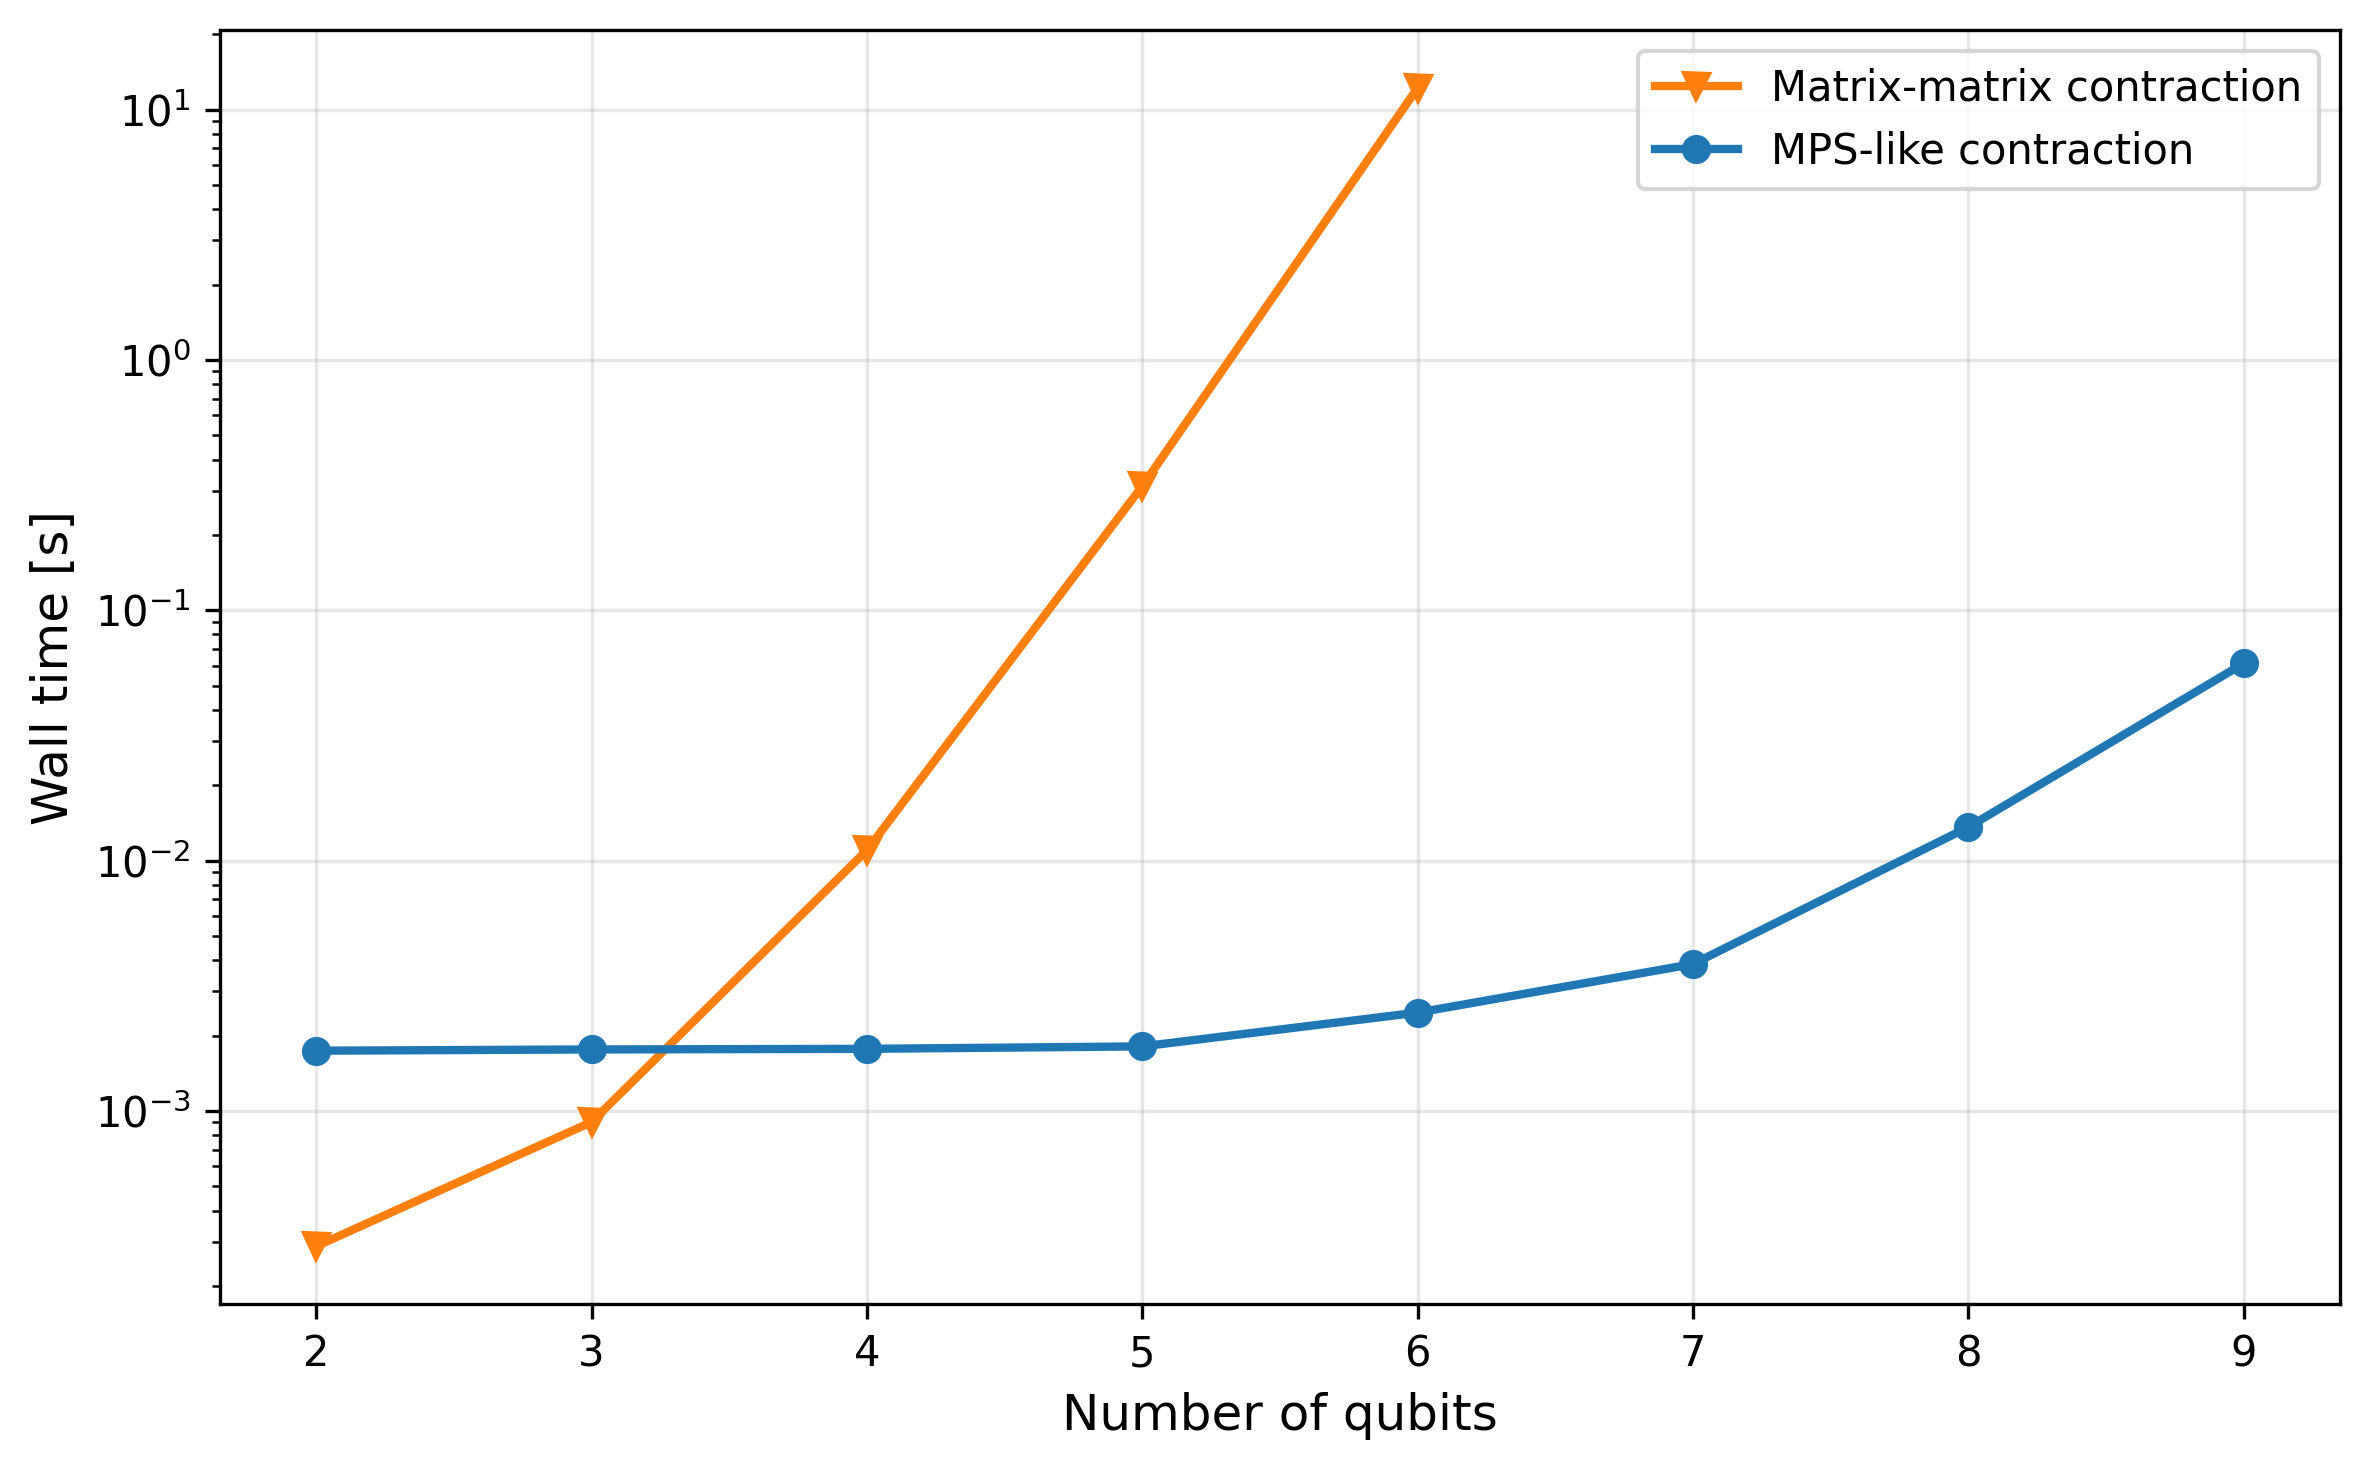

In [10]:
import jax.numpy as jnp
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(8, 5), dpi=300)

max_num_qubits = 6

times_naive = jnp.array([288e-6, 903e-6, 11e-3, 313e-3, 12.2])
times_mps = jnp.array([2.03, 2.12, 2.14, 2.23, 2.41])/1000

# times_mps_single_einsum_dot = jnp.array([1.82, 1.88, 1.86, 1.99, 2.4])/1000
times_mps_matrix= jnp.array([1.84, 1.95, 1.99, 2.11, 2.53, 4.19, 16.1, 72])/1000
# times_mps_hadamard= jnp.array([1.8, 1.83, 1.82, 1.89, 2.49,4.31, 15.8])/1000
times_mps_opt_path= jnp.array([1.74, 1.76, 1.77, 1.81, 2.47, 3.86, 13.6, 61.3])/1000


times_naive_einsum_nonvec= jnp.array([733e-6, 998e-6, 10.7e-3, 324e-3, 12.5])



# plt.semilogy(range(2, max_num_qubits+1), times_mps, label="MPS-like", color="#1f77b4", linestyle="-", marker="o", linewidth=2, markersize=6)
plt.semilogy(range(2, max_num_qubits+1), times_naive, label="Matrix-matrix contraction", color="#ff7f0e", linestyle="-", marker="v", linewidth=2, markersize=6)
# plt.semilogy(range(2, max_num_qubits+1), times_naive_einsum_nonvec, label="Naive: einsum + nonvec", color="#d62728", linestyle="-", marker="d", linewidth=2, markersize=6)
# plt.semilogy(range(2, max_num_qubits+1), times_mps_single_einsum_dot, label="MPS-like: dot +  single einsum", color="#9467bd", linestyle="-", marker="x", linewidth=2, markersize=6)
# plt.semilogy(range(2, max_num_qubits+4), times_mps_matrix, label="MPS-like: matrix", color="#2ca02c", linestyle="-", marker="o", linewidth=2, markersize=6)
# plt.semilogy(range(2, max_num_qubits+4), times_mps_opt_path, label="MPS-like: hadamard product + opt_path", color="#1f77b4", linestyle="-", marker="o", linewidth=2, markersize=6)
plt.semilogy(range(2, max_num_qubits+4), times_mps_opt_path, label="MPS-like contraction", color="#1f77b4", linestyle="-", marker="o", linewidth=2, markersize=6)


# Add labels, legend, and grid
plt.xlabel("Number of qubits", fontsize=12)
plt.ylabel("Wall time [s]", fontsize=12)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)

# Show the plot
plt.tight_layout()
plt.show()

# Benchmark performance of different operations

In [131]:
key = jax.random.PRNGKey(42)

num_qubits = 2
dim = 2**(2*num_qubits)
vector = jax.random.uniform(key, [dim])

%timeit jnp.einsum("i->", vector)

%timeit jnp.sum(vector)

%timeit sum(vector)

59.7 μs ± 3.93 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
5.03 μs ± 41.3 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
125 μs ± 7.66 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [123]:
num_qubits = 3
dim = 2**(2*num_qubits)
vector = jax.random.uniform(key, [dim])

%timeit jnp.einsum("i->", vector)

%timeit jnp.sum(vector)

%timeit sum(vector)

56 μs ± 208 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
5.25 μs ± 440 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
436 μs ± 12.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [124]:
num_qubits = 4
dim = 2**(2*num_qubits)
vector = jax.random.uniform(key, [dim])

%timeit jnp.einsum("i->", vector)

%timeit jnp.sum(vector)

%timeit sum(vector)

54.6 μs ± 663 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
5.03 μs ± 24.4 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
2.29 ms ± 144 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [125]:
num_qubits = 5
dim = 2**(2*num_qubits)
vector = jax.random.uniform(key, [dim])

%timeit jnp.einsum("i->", vector)

%timeit jnp.sum(vector)

%timeit sum(vector)

62.1 μs ± 217 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
12.4 μs ± 158 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
8.12 ms ± 30.9 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [126]:
num_qubits = 6
dim = 2**(2*num_qubits)
vector = jax.random.uniform(key, [dim])

%timeit jnp.einsum("i->", vector)

%timeit jnp.sum(vector)

%timeit sum(vector)

62.6 μs ± 104 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
12.5 μs ± 285 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
32.5 ms ± 210 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [128]:
num_qubits = 7
dim = 2**(2*num_qubits)
vector = jax.random.uniform(key, [dim])

%timeit jnp.einsum("i->", vector)

%timeit jnp.sum(vector)

%timeit sum(vector)

63.2 μs ± 363 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
13.6 μs ± 271 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
131 ms ± 1.01 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [130]:
num_qubits = 8
dim = 2**(2*num_qubits)
vector = jax.random.uniform(key, [dim])

%timeit jnp.einsum("i->", vector)

%timeit jnp.sum(vector)

%timeit sum(vector)

66.8 μs ± 1.02 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
42.1 μs ± 57.6 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
520 ms ± 11 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


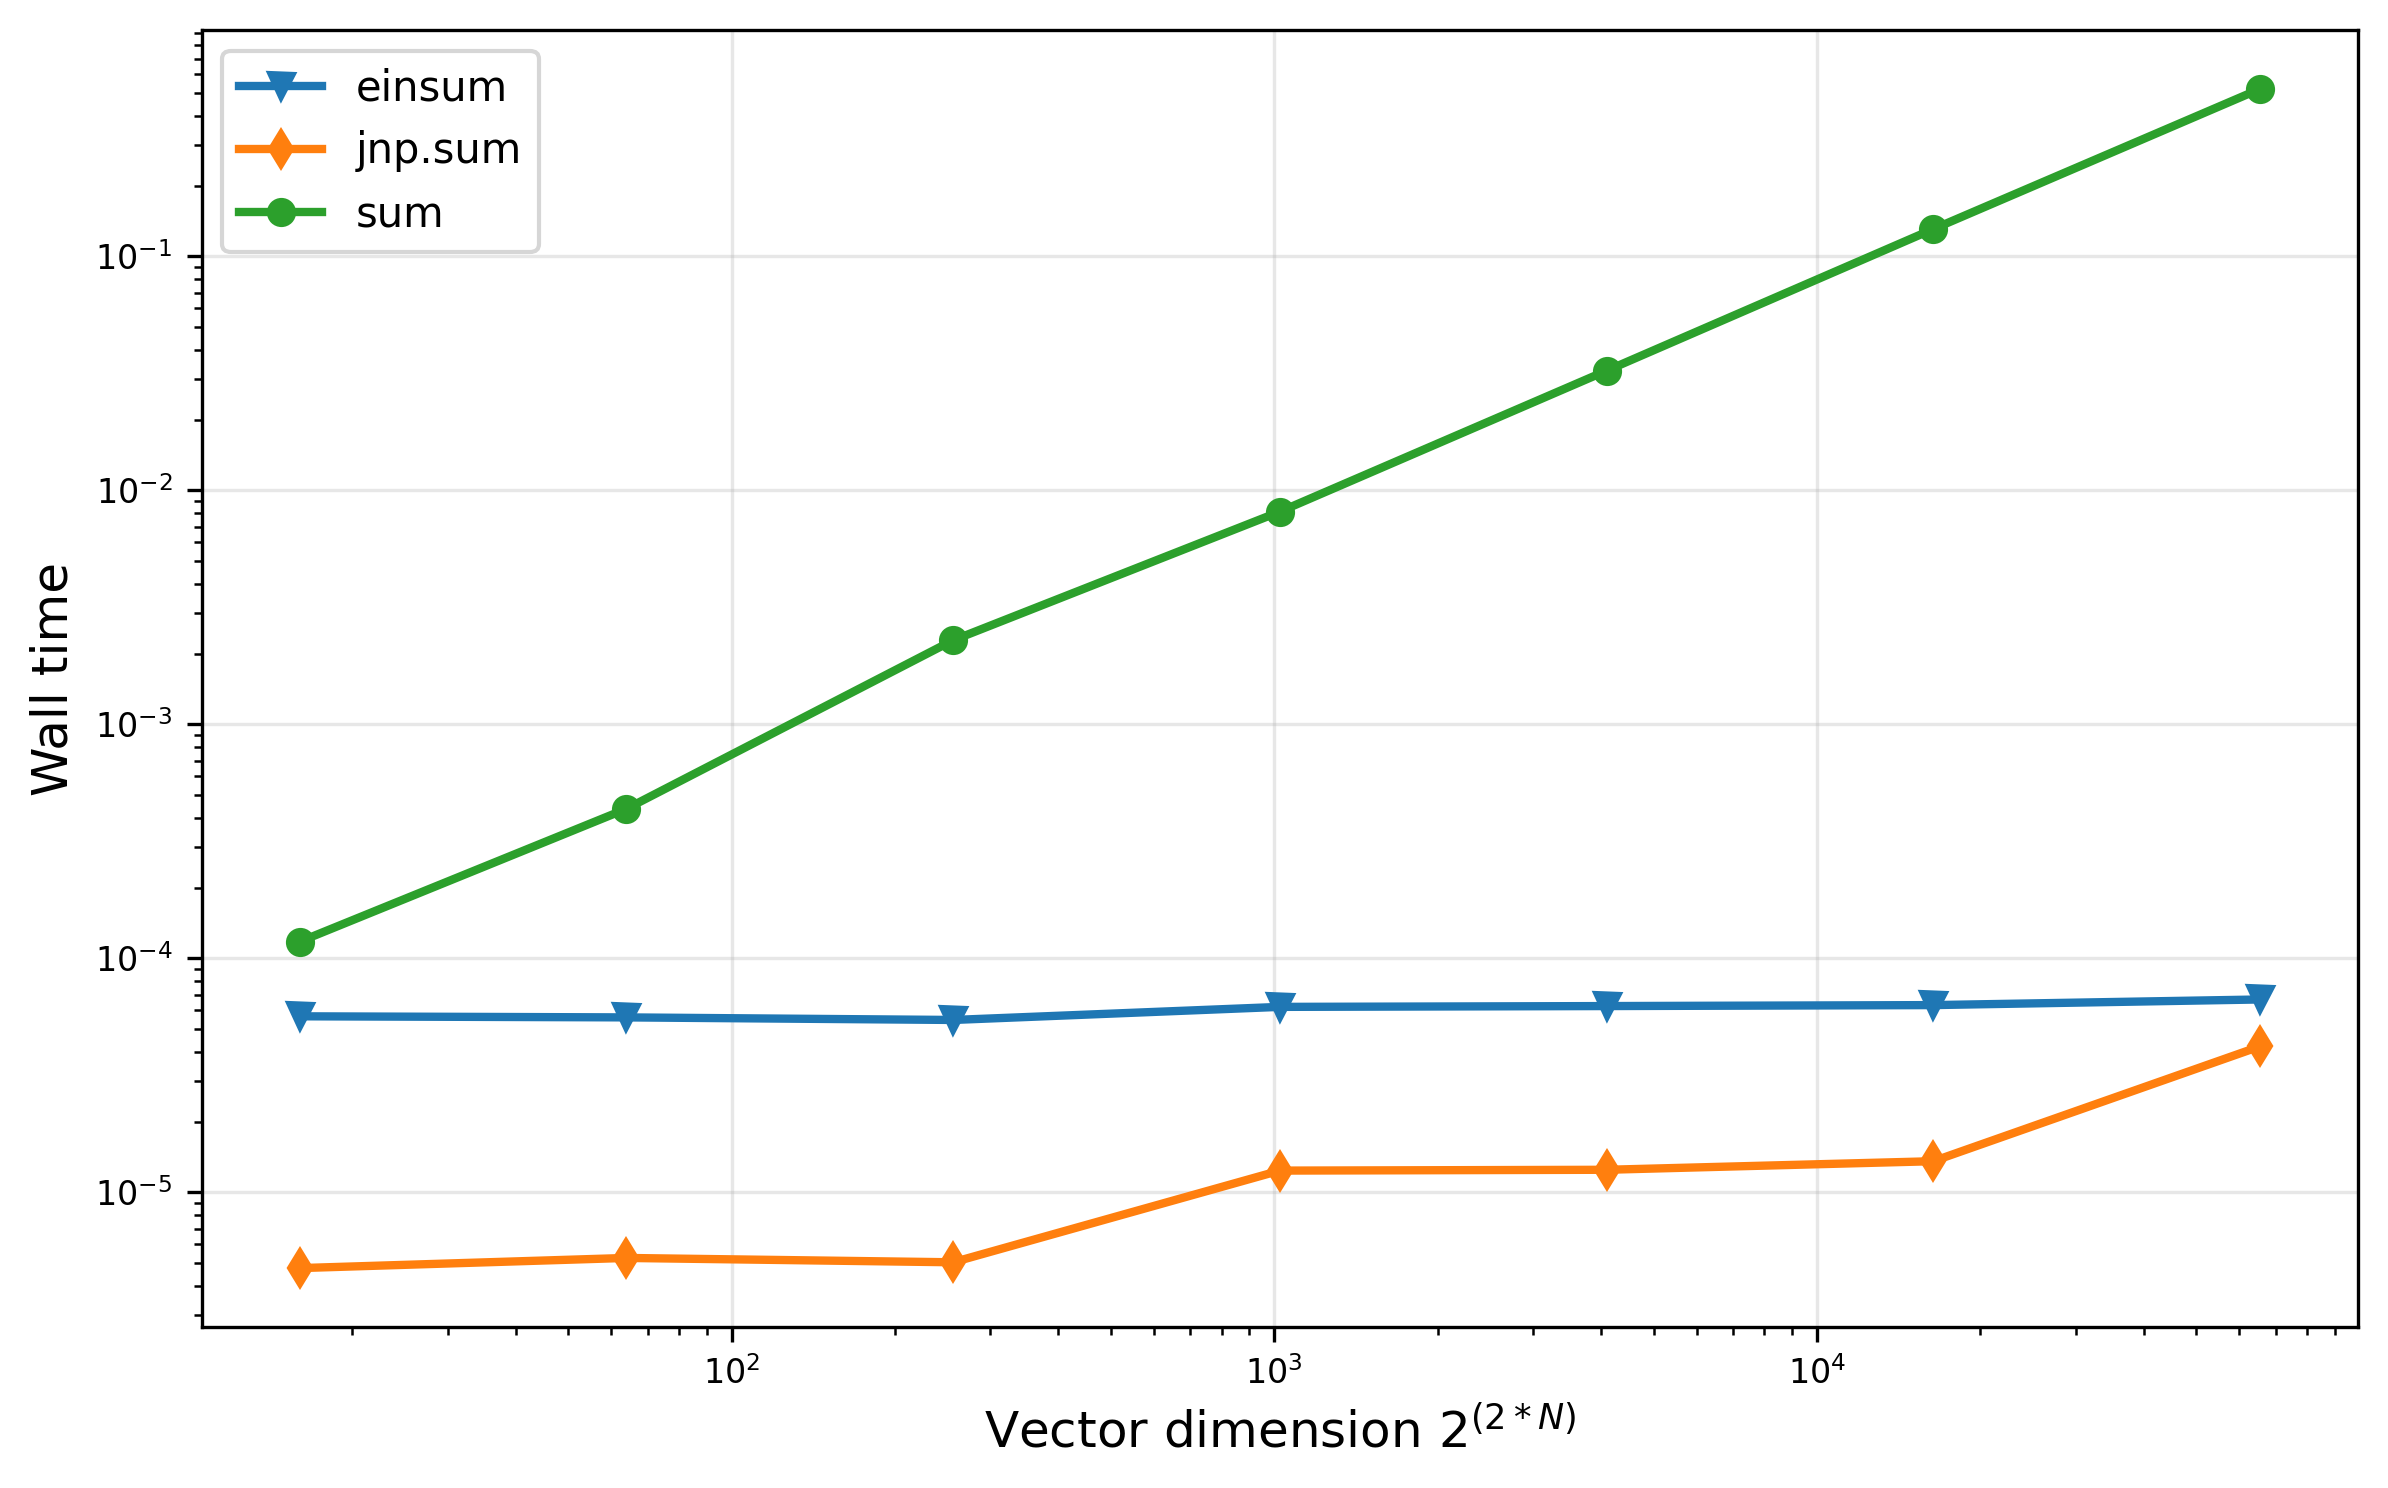

In [139]:
# Create the plot
plt.figure(figsize=(8, 5), dpi=300)

max_num_qubits = 4

times_einsum = jnp.array([56.6, 56, 54.6, 62.1, 62.6, 63.2, 66.8])/1e6
times_jnp_sum = jnp.array([4.75, 5.25, 5.03, 12.4, 12.5, 13.6, 42.1])/1e6
times_sum = jnp.array([118,436, 2.29e3, 8.12e3, 32.5e3, 131e3, 520e3])/1e6

vector_dimension = 2**(2*jnp.arange(2,9))

plt.loglog(vector_dimension, times_einsum, label="einsum", linestyle="-", marker="v", linewidth=2, markersize=6)
plt.loglog(vector_dimension, times_jnp_sum, label="jnp.sum", linestyle="-", marker="d", linewidth=2, markersize=6)
plt.loglog(vector_dimension, times_sum, label="sum", linestyle="-", marker="o", linewidth=2, markersize=6)


# Add labels, legend, and grid
plt.xlabel(r"Vector dimension $2^{(2 * N)}$", fontsize=12)
plt.ylabel("Wall time", fontsize=12)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)

# Show the plot
plt.tight_layout()
plt.show()

In [69]:
key = jax.random.PRNGKey(42)

A = jax.random.uniform(key, [1000,1000])
B = jax.random.uniform(key, [1000,1000])

%timeit jnp.dot(A,B)

%timeit A.dot(B)

%timeit jnp.einsum("ij,jk",A,B)

%timeit A @ B

7.36 ms ± 22 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
7.41 ms ± 67.4 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
7.39 ms ± 43.4 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
7.38 ms ± 57.6 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [168]:
A = jax.random.uniform(key, [1000,1000])
B = jax.random.uniform(key, [1000,1000])

%timeit jnp.einsum("ij,ji->",A,B)

%timeit jnp.trace(A @ B)

%timeit jnp.reshape(A.T, -1) @ jnp.reshape(B, -1)

A_vec = jnp.reshape(A.T, -1)
B_vec = jnp.reshape(B, -1)

%timeit jnp.dot(A_vec, B_vec)

%timeit A_vec @ B_vec

%timeit jnp.sum(A * B.T)

1.68 ms ± 30.6 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
7.91 ms ± 242 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
2.21 ms ± 189 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
1.18 ms ± 4.66 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.18 ms ± 1.9 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1 ms ± 8.13 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [167]:
jnp.allclose(jnp.sum(A * B.T), jnp.einsum("ij,ji->", A,B))

Array(True, dtype=bool)

In [169]:
A = jax.random.uniform(key, [2000,1000])
B = jax.random.uniform(key, [1000,2000])

%timeit jnp.einsum("ij,ji->",A,B)

%timeit jnp.trace(A @ B)

%timeit jnp.reshape(A.T, -1) @ jnp.reshape(B, -1)

A_vec = jnp.reshape(A.T, -1)
B_vec = jnp.reshape(B, -1)

%timeit jnp.dot(A_vec, B_vec)

%timeit A_vec @ B_vec

%timeit jnp.sum(A * B.T)

3.35 ms ± 82.2 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
30.2 ms ± 932 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
4.28 ms ± 19.1 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
2.39 ms ± 5.13 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
2.39 ms ± 7.33 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
2.1 ms ± 10.8 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [170]:
%timeit jnp.vdot(A, B)

The slowest run took 5.68 times longer than the fastest. This could mean that an intermediate result is being cached.
8.27 μs ± 6.37 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [171]:
%timeit jnp.vdot(A, B)

2.34 ms ± 12.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [128]:
# Now I want to test quickly how a for loop compares to a tensor operation
num_copies = 3
A_list = [A]*3
A_tensor = jnp.array(A_list) # num_copies, dim, dim

def for_loop_fn(A_tensor, B):
    output_list = []
    for A in A_tensor:
        output_list.append(A @ B)
    return jnp.array(output_list)
        
def tensor_fn(A_tensor, B):
    return jnp.tensordot(A_tensor, B, axes=([-1],[0]))

jnp.allclose(for_loop_fn(A_tensor, B), tensor_fn(A_tensor, B))

Array(True, dtype=bool)

In [129]:
%timeit for_loop_fn(A_tensor, B)
%timeit tensor_fn(A_tensor, B)

88.7 ms ± 212 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
82.1 ms ± 660 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [130]:
num_copies = 5
A_list = [A]*num_copies
A_tensor = jnp.array(A_list) # num_copies, dim, dim

In [131]:
%timeit for_loop_fn(A_tensor, B)
%timeit tensor_fn(A_tensor, B)

157 ms ± 295 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
141 ms ± 2.63 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [9]:
import numpy as np
A = np.random.random([1000,1000])
B = np.random.random([1000,1000])

%timeit np.dot(A,B)

%timeit A.dot(B)

%timeit np.einsum("ij,jk",A,B)

%timeit A @ B

17.5 ms ± 1.44 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
18.1 ms ± 1.62 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
153 ms ± 6.21 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
16.7 ms ± 361 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [10]:
matrix_1 = np.random.random([3,4])
matrix_2 = np.random.random([4,5])

matrix_1 @ matrix_2

array([[0.7900092 , 1.01838305, 0.94787053, 0.82512841, 0.57482204],
       [1.33909362, 1.73355851, 1.46439781, 1.31868596, 0.97113692],
       [0.71194852, 1.04261973, 1.0514495 , 0.9602178 , 0.52558704]])

In [ ]:
# comparing: einsum vs reordering of legs-merging-matrix multiplication

In [22]:
def matrix_multiplication_of_tensor(T1, T2, dot:bool=False):
    """Matrix-like multiplication of two tensors

    Args:
        T1: assume is a tensor of dimensions (d1, d2, d3)
        T2: assume is a tensor of dimensions (d3, d4)
    """
    d1, d2, d3 = T1.shape
    matrix_T1 = jnp.reshape(T1, shape=(d1*d2, d3))
    if dot:
        return matrix_T1.dot(T2)
    return matrix_T1 @ T2

In [13]:
key = jax.random.PRNGKey(42)

T1 = jax.random.uniform(key, [100,200,500])
T2 = jax.random.uniform(key, [500,1000])

%timeit matrix_multiplication_of_tensor(T1, T2)

71.9 ms ± 284 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [20]:
%timeit matrix_multiplication_of_tensor(T1, T2, dot=True)

The slowest run took 6.18 times longer than the fastest. This could mean that an intermediate result is being cached.
40.5 μs ± 35 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [23]:
%timeit matrix_multiplication_of_tensor(T1, T2, dot=True)

74.7 ms ± 3.17 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [14]:
%timeit jnp.einsum("ijk,kl->ijl", T1, T2)

70.2 ms ± 524 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [15]:
w = jnp.arange(5, 9).reshape(2, 2)
x = jnp.arange(6).reshape(2, 3)
y = jnp.arange(-2, 4).reshape(3, 2)
z = jnp.array([[2, 4, 6], [3, 5, 7]])

%timeit jnp.einsum('ij,jk,kl,lm->im', w, x, y, z)

%timeit jnp.einsum(w, (0, 1), x, (1, 2), y, (2, 3), z, (3, 4))  # implicit, via indices

%timeit w @ x @ y @ z  # direct chain of matmuls

%timeit jnp.linalg.multi_dot([w, x, y, z])

142 μs ± 2.93 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
143 μs ± 272 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
12.3 μs ± 402 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
203 μs ± 1.32 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [17]:
def chain_contraction(w,x,y,z):
    t1 = jnp.einsum('ij,jk->ik',w,x)
    t2 = jnp.einsum('ik,kl->il', t1, y)
    return jnp.einsum('il,lm->im', t2, z)

%timeit chain_contraction(w,x,y,z)

187 μs ± 463 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [1]:
import jax
import jax.numpy as jnp
import time

def benchmark_reshape_and_transpose(max_power):
    """
    Benchmarks jnp.reshape and jnp.transpose operations for 3D arrays.
    
    Parameters:
        max_power (int): Maximum power of 10 for D (size of the array dimensions).
    """
    times_reshape = []
    times_transpose = []
    sizes = []

    for power in range(1, max_power + 1):
        D = 10 ** power
        sizes.append(D)
        
        # Generate a 3D array of size D x D x D
        key = jax.random.PRNGKey(42)
        array = jax.random.normal(key, shape=(D, D, D))
        
        # Benchmark jnp.reshape
        start = time.time()
        reshaped = jnp.reshape(array, (D, D * D))
        jax.block_until_ready(reshaped)  # Ensure computation completes
        end = time.time()
        times_reshape.append(end - start)
        
        # Benchmark jnp.transpose
        start = time.time()
        transposed = jnp.transpose(array, axes=(2, 0, 1))
        jax.block_until_ready(transposed)  # Ensure computation completes
        end = time.time()
        times_transpose.append(end - start)

        print(f"D={D}: reshape={times_reshape[-1]:.6f}s, transpose={times_transpose[-1]:.6f}s")
    
    return sizes, times_reshape, times_transpose

# Run the benchmark
max_power = 3  # Adjust the maximum power as needed
sizes, times_reshape, times_transpose = benchmark_reshape_and_transpose(max_power)

D=10: reshape=0.014387s, transpose=0.017719s
D=100: reshape=0.014459s, transpose=0.020580s
D=1000: reshape=13.291264s, transpose=21.570421s


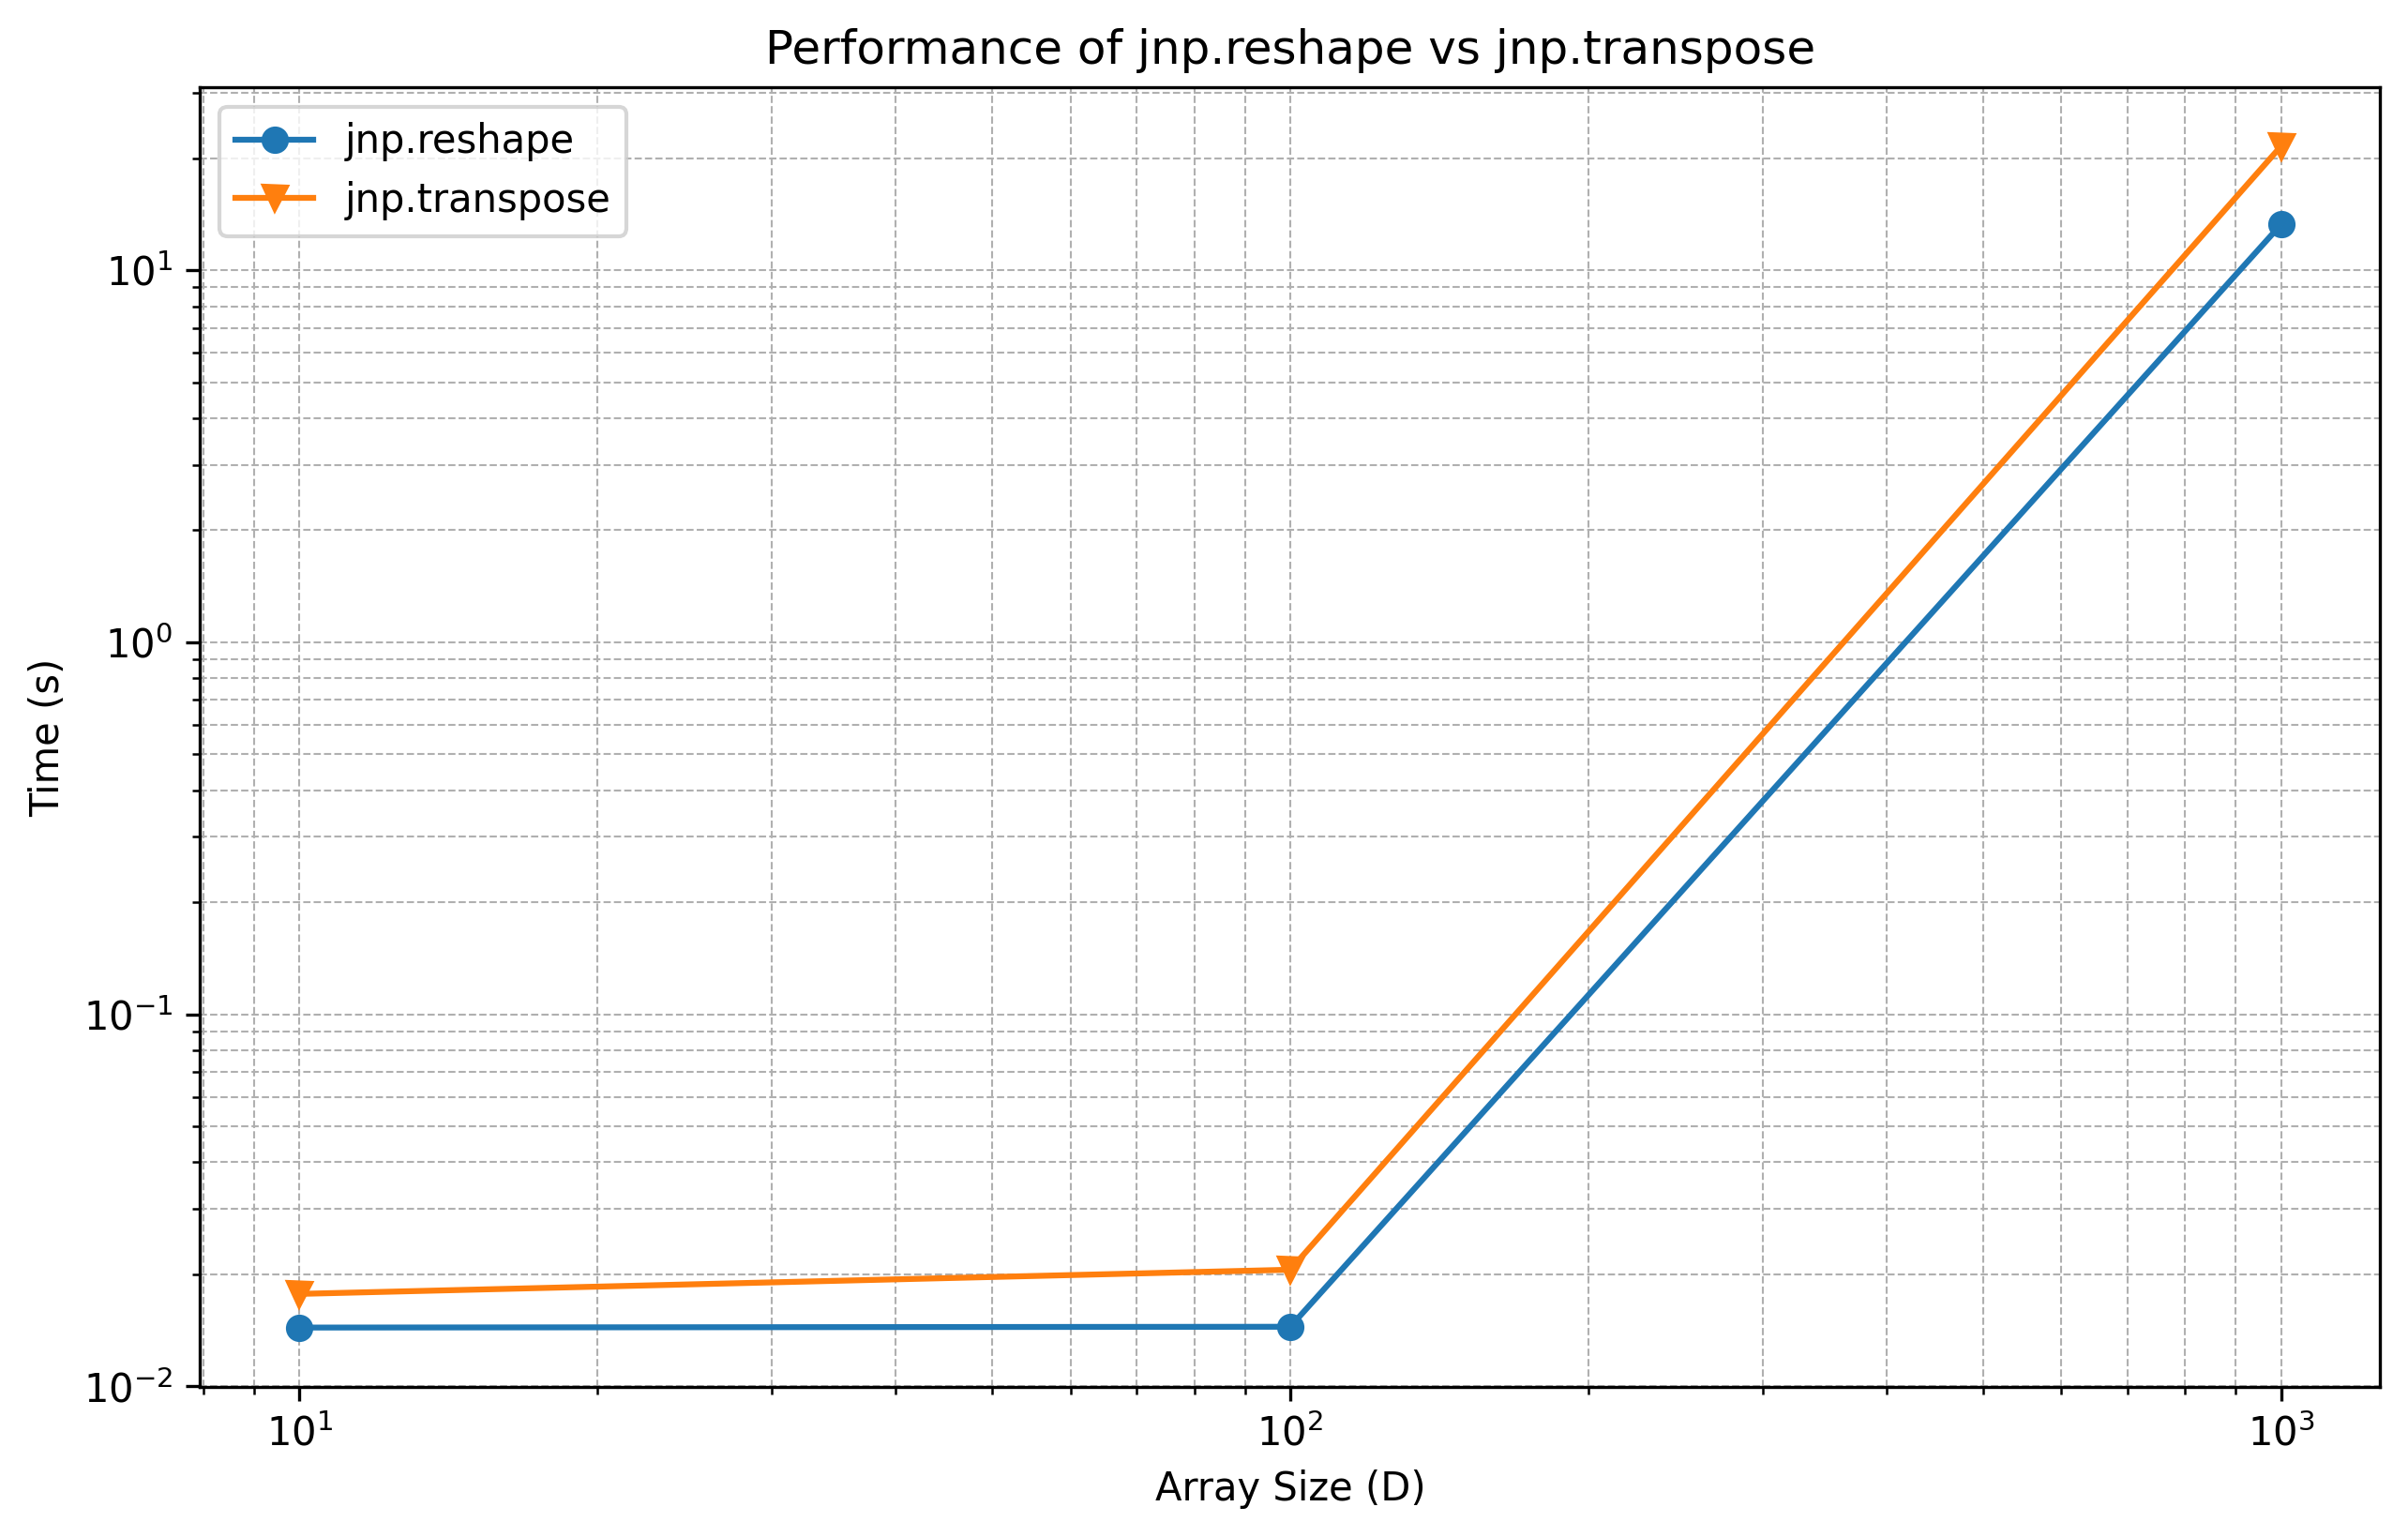

In [3]:
# Plot the results
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6), dpi=300)
plt.plot(sizes, times_reshape, label="jnp.reshape", marker="o", color="#1f77b4")
plt.plot(sizes, times_transpose, label="jnp.transpose", marker="v", color="#ff7f0e")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Array Size (D)")
plt.ylabel("Time (s)")
plt.title("Performance of jnp.reshape vs jnp.transpose")
plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()

# Benchmark all-POVM contraction

## 2GST

In [104]:
# Euclidean Gradient
Q2_GST = GSTConfiguration(
    qubit_layouts=[[0, 1]],
    gate_set="2QXYCZ",
    num_circuits=800,
    shots=1000,
    rank=4,
)

K, X, E, rho, y, J, l, d, pdim, r, n_povm, bsize, meas_samples, n, nt, rK = get_full_mgst_parameters_from_configuration(
    Q2_GST, backend
)

2025-01-29 17:46:21,062 - iqm.benchmarks.logging_config - INFO - Now generating 800 random GST circuits...
2025-01-29 17:46:21,226 - iqm.benchmarks.logging_config - INFO - Will transpile all 800 circuits according to fixed physical layout
2025-01-29 17:46:21,226 - iqm.benchmarks.logging_config - INFO - Transpiling for backend IQMFakeApolloBackend with optimization level 0, sabre routing method all circuits
2025-01-29 17:46:23,515 - iqm.benchmarks.logging_config - INFO - Submitting batch with 800 circuits corresponding to qubits [0, 1]
2025-01-29 17:46:23,517 - iqm.benchmarks.logging_config - INFO - Now executing the corresponding circuit batch
2025-01-29 17:46:23,523 - iqm.benchmarks.logging_config - INFO - Retrieving all counts


In [112]:
depth = K.shape[0]
dim_squared = K.shape[-1]**2
depth, dim_squared, K.shape, E.shape, len(J)

(5, 16, (5, 4, 4, 4), (4, 16), 800)

In [106]:
# The idea is to now compare how long each of the contractions take.
idx_gate = -2
gate_indices = J[idx_gate] # Each J is a set of indices of length l (max depth)
gate_indices, len(gate_indices)

(array([3, 0, 0, 0, 3, 4, 0, 0, 2, 4, 2, 1, 3, 0]), 14)

In [107]:
# running this to have a comparison for the value
naive_vector = contract_kraus_state_all_povm(kraus=K, gate_indices=gate_indices, povm_tensor=E, state=rho)
naive_vector

Array([0.01086349+2.99239800e-17j, 0.49419912-6.59194921e-17j,
       0.01399985-3.90312782e-17j, 0.48093754+4.94396191e-17j],      dtype=complex128)

In [108]:
%timeit contract_kraus_state_all_povm(kraus=K, gate_indices=gate_indices, povm_tensor=E, state=rho)

3.69 ms ± 27.1 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [109]:
dim = int(jnp.sqrt(dim_squared))
# reshape POVM and state
num_povm = E.shape[0]
povm_rank3 = jnp.reshape(E, shape=(num_povm,dim,dim))
state_rank2 = jnp.reshape(rho, shape=(dim, dim))
povm_rank3.shape

(4, 4, 4)

In [110]:
mps_vector_loop = contract_mps_all_povm(kraus=K, gate_indices=gate_indices, povm_tensor=povm_rank3, state=state_rank2, loop=True)
mps_vector_broadcast = contract_mps_all_povm(kraus=K, gate_indices=gate_indices, povm_tensor=povm_rank3, state=state_rank2, broadcast=True)
mps_vector_einsum = contract_mps_all_povm(kraus=K, gate_indices=gate_indices, povm_tensor=povm_rank3, state=state_rank2, broadcast=False)

jnp.allclose(mps_vector_loop, mps_vector_broadcast), jnp.allclose(mps_vector_broadcast, mps_vector_einsum), jnp.allclose(mps_vector_broadcast, naive_vector)

(Array(True, dtype=bool), Array(True, dtype=bool), Array(True, dtype=bool))

In [111]:
# now it's time to timeit each of them

%timeit contract_mps_all_povm(kraus=K, gate_indices=gate_indices, povm_tensor=povm_rank3, state=state_rank2, loop=True)

%timeit contract_mps_all_povm(kraus=K, gate_indices=gate_indices, povm_tensor=povm_rank3, state=state_rank2, broadcast=True)

%timeit contract_mps_all_povm(kraus=K, gate_indices=gate_indices, povm_tensor=povm_rank3, state=state_rank2, broadcast=False)

1.56 ms ± 19.2 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.28 ms ± 3.06 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.32 ms ± 4.18 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


## 3GST

In [113]:
Q3_GST = GSTConfiguration(
    qubit_layouts=[[0,1,3]],
    gate_set="3QXYCZ",
    num_circuits=1000,
    shots=1000,
    rank=4,
)

K, X, E, rho, y, J, l, depth, pdim, dim_squared, n_povm, bsize, meas_samples, n, nt, rK = get_full_mgst_parameters_from_configuration(
    Q3_GST, backend
)

2025-01-29 18:02:13,532 - iqm.benchmarks.logging_config - INFO - Now generating 1000 random GST circuits...
2025-01-29 18:02:13,787 - iqm.benchmarks.logging_config - INFO - Will transpile all 1000 circuits according to fixed physical layout
2025-01-29 18:02:13,787 - iqm.benchmarks.logging_config - INFO - Transpiling for backend IQMFakeApolloBackend with optimization level 0, sabre routing method all circuits
2025-01-29 18:02:16,156 - iqm.benchmarks.logging_config - INFO - Submitting batch with 1000 circuits corresponding to qubits [0, 1, 3]
2025-01-29 18:02:16,161 - iqm.benchmarks.logging_config - INFO - Now executing the corresponding circuit batch
2025-01-29 18:02:16,185 - iqm.benchmarks.logging_config - INFO - Retrieving all counts


In [114]:
depth = K.shape[0]
dim_squared = K.shape[-1]**2
depth, dim_squared, K.shape, E.shape, len(J)

(8, 64, (8, 4, 8, 8), (8, 64), 1000)

In [93]:
# The idea is to now compare how long each of the contractions take.
idx_gate = -2
gate_indices = J[idx_gate] # Each J is a set of indices of length l (max depth)
gate_indices, len(gate_indices)

(array([7, 1, 0, 2, 3, 5, 6, 0, 2, 1, 7, 7, 5, 1]), 14)

In [66]:
# running this to have a comparison for the value
naive_vector = contract_kraus_state_all_povm(kraus=K, gate_indices=gate_indices, povm_tensor=E, state=rho)
naive_vector

Array([0.00417768-9.62229428e-19j, 0.00416032-4.07931067e-18j,
       0.0036112 +6.97955149e-19j, 0.00419195+2.71050543e-20j,
       0.49269053+1.37287100e-17j, 0.47736523+4.09286320e-18j,
       0.00774371-2.11673534e-17j, 0.00605937+3.37525689e-17j],      dtype=complex128)

In [94]:
%timeit contract_kraus_state_all_povm(kraus=K, gate_indices=gate_indices, povm_tensor=E, state=rho)

14.8 ms ± 96.3 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [80]:
dim = int(jnp.sqrt(dim_squared))
# reshape POVM and state
num_povm = E.shape[0]
povm_rank3 = jnp.reshape(E, shape=(num_povm,dim,dim))
state_rank2 = jnp.reshape(rho, shape=(dim, dim))
povm_rank3.shape

(8, 8, 8)

In [82]:
mps_vector_loop = contract_mps_all_povm(kraus=K, gate_indices=gate_indices, povm_tensor=povm_rank3, state=state_rank2, loop=True)
mps_vector_broadcast = contract_mps_all_povm(kraus=K, gate_indices=gate_indices, povm_tensor=povm_rank3, state=state_rank2, broadcast=True)
mps_vector_einsum = contract_mps_all_povm(kraus=K, gate_indices=gate_indices, povm_tensor=povm_rank3, state=state_rank2, broadcast=False)

jnp.allclose(mps_vector_loop, mps_vector_broadcast), jnp.allclose(mps_vector_broadcast, mps_vector_einsum)

(Array(True, dtype=bool), Array(True, dtype=bool))

In [83]:
jnp.allclose(mps_vector_broadcast, naive_vector)

Array(True, dtype=bool)

In [84]:
# now it's time to timeit each of them

%timeit contract_mps_all_povm(kraus=K, gate_indices=gate_indices, povm_tensor=povm_rank3, state=state_rank2, loop=True)

%timeit contract_mps_all_povm(kraus=K, gate_indices=gate_indices, povm_tensor=povm_rank3, state=state_rank2, broadcast=True)

%timeit contract_mps_all_povm(kraus=K, gate_indices=gate_indices, povm_tensor=povm_rank3, state=state_rank2, broadcast=False)

1.78 ms ± 149 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.29 ms ± 43.3 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.29 ms ± 44.2 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


## 4GST

In [119]:
Q4_GST = create_4q_gst_config()

K, X, E, rho, y, J, l, depth, pdim, dim_squared, n_povm, bsize, meas_samples, n, nt, rK = get_full_mgst_parameters_from_configuration(
    Q4_GST, backend
)

2025-01-29 18:15:57,186 - iqm.benchmarks.logging_config - INFO - Now generating 2000 random GST circuits...
2025-01-29 18:15:57,672 - iqm.benchmarks.logging_config - INFO - Will transpile all 2000 circuits according to fixed physical layout
2025-01-29 18:15:57,672 - iqm.benchmarks.logging_config - INFO - Transpiling for backend IQMFakeApolloBackend with optimization level 0, sabre routing method all circuits
2025-01-29 18:16:01,260 - iqm.benchmarks.logging_config - INFO - Submitting batch with 2000 circuits corresponding to qubits [0, 1, 3, 4]
2025-01-29 18:16:01,264 - iqm.benchmarks.logging_config - INFO - Now executing the corresponding circuit batch
2025-01-29 18:16:01,302 - iqm.benchmarks.logging_config - INFO - Retrieving all counts


In [120]:
depth = K.shape[0]
dim_squared = K.shape[-1]**2
depth, dim_squared, K.shape, E.shape, len(J)

(9, 256, (9, 1, 16, 16), (16, 256), 2000)

In [97]:
# The idea is to now compare how long each of the contractions take.
idx_gate = -2
gate_indices = J[idx_gate] # Each J is a set of indices of length l (max depth)
gate_indices, len(gate_indices) # the length of this is the actual depth, keep in mind what I call depth was a misconception

(array([7, 0, 6, 3, 8, 4, 8, 7, 8, 8, 4, 0, 5, 4]), 14)

In [98]:
# running this to have a comparison for the value
naive_vector = contract_kraus_state_all_povm(kraus=K, gate_indices=gate_indices, povm_tensor=E, state=rho)
naive_vector

Array([0.01963613+1.37368415e-16j, 0.00462368+1.57886941e-17j,
       0.00026009+3.84078620e-17j, 0.00405174-2.79724161e-17j,
       0.00204028-1.91903785e-17j, 0.00171513+2.82705716e-17j,
       0.0029494 +4.21483595e-18j, 0.00159947-1.30104261e-18j,
       0.11014259+2.03830008e-17j, 0.12806804-7.57315217e-17j,
       0.15334657+9.38919081e-17j, 0.15411407-1.89735380e-17j,
       0.13197397+1.02186055e-17j, 0.08609761+7.24789152e-17j,
       0.11537587-5.78150808e-17j, 0.08400536-6.10405823e-17j],      dtype=complex128)

In [99]:
%timeit contract_kraus_state_all_povm(kraus=K, gate_indices=gate_indices, povm_tensor=E, state=rho)

382 ms ± 47.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [100]:
dim = int(jnp.sqrt(dim_squared))
# reshape POVM and state
num_povm = E.shape[0]
povm_rank3 = jnp.reshape(E, shape=(num_povm,dim,dim))
state_rank2 = jnp.reshape(rho, shape=(dim, dim))
povm_rank3.shape

(16, 16, 16)

In [101]:
mps_vector_loop = contract_mps_all_povm(kraus=K, gate_indices=gate_indices, povm_tensor=povm_rank3, state=state_rank2, loop=True)
mps_vector_broadcast = contract_mps_all_povm(kraus=K, gate_indices=gate_indices, povm_tensor=povm_rank3, state=state_rank2, broadcast=True)
mps_vector_einsum = contract_mps_all_povm(kraus=K, gate_indices=gate_indices, povm_tensor=povm_rank3, state=state_rank2, broadcast=False)

jnp.allclose(mps_vector_loop, mps_vector_broadcast), jnp.allclose(mps_vector_broadcast, mps_vector_einsum)

(Array(True, dtype=bool), Array(True, dtype=bool))

In [102]:
jnp.allclose(mps_vector_broadcast, naive_vector)

Array(True, dtype=bool)

In [103]:
# now it's time to timeit each of them

%timeit contract_mps_all_povm(kraus=K, gate_indices=gate_indices, povm_tensor=povm_rank3, state=state_rank2, loop=True)

%timeit contract_mps_all_povm(kraus=K, gate_indices=gate_indices, povm_tensor=povm_rank3, state=state_rank2, broadcast=True)

%timeit contract_mps_all_povm(kraus=K, gate_indices=gate_indices, povm_tensor=povm_rank3, state=state_rank2, broadcast=False)

2.76 ms ± 420 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
1.32 ms ± 16.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.34 ms ± 11.4 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


## Comparison

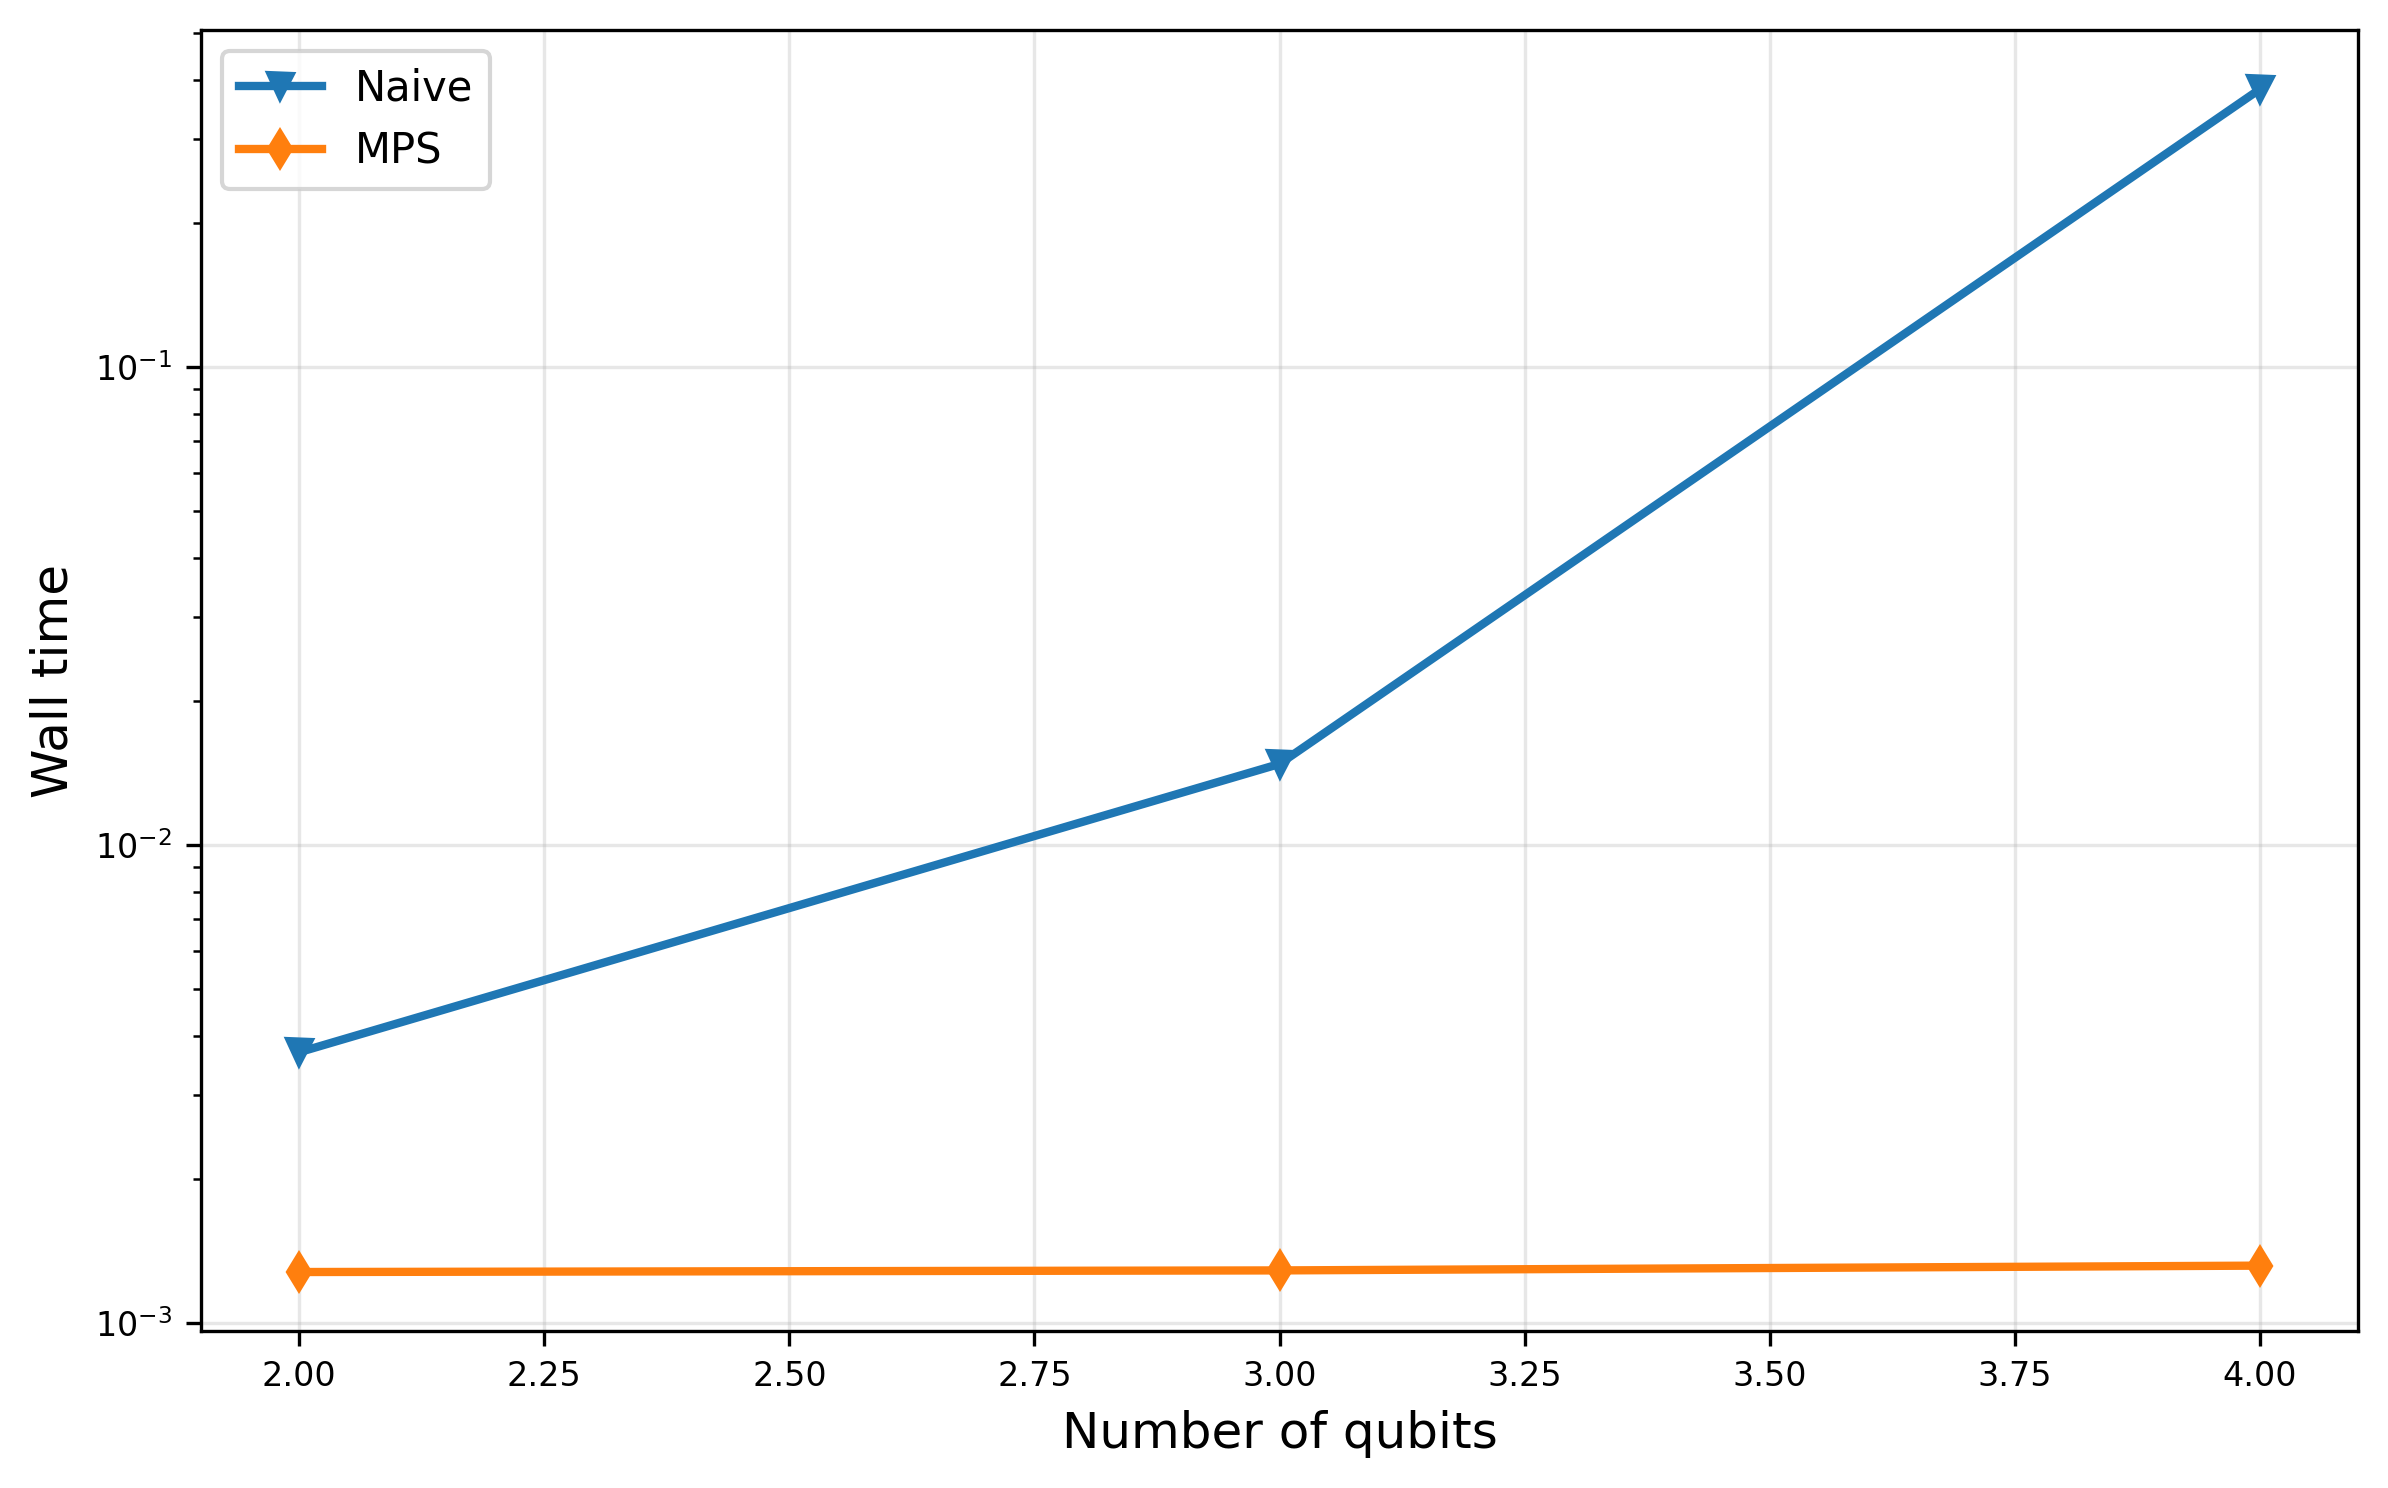

In [117]:
# Create the plot
plt.figure(figsize=(8, 5), dpi=300)

max_num_qubits = 4

times_naive = jnp.array([3.69, 14.8, 382])/1000
times_mps = jnp.array([1.28, 1.29, 1.32])/1000

plt.semilogy(range(2, max_num_qubits+1), times_naive, label="Naive", linestyle="-", marker="v", linewidth=2, markersize=6)
plt.semilogy(range(2, max_num_qubits+1), times_mps, label="MPS", linestyle="-", marker="d", linewidth=2, markersize=6)

# Add labels, legend, and grid
plt.xlabel("Number of qubits", fontsize=12)
plt.ylabel("Wall time", fontsize=12)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)

# Show the plot
plt.tight_layout()
plt.show()

# Full cost function comparison (excited ...)

In [8]:
from mGST.low_level_jit import cost_function_numba, cost_function_jax_mps, gradient_k_mps_jit, gradient_k_numba, gradient_k_mps

## 2GST

In [5]:
# first let's calculate the cost function using numba
# Euclidean Gradient
Q2_GST = GSTConfiguration(
    qubit_layouts=[[0, 1]],
    gate_set="2QXYCZ",
    num_circuits=800,
    shots=1000,
    rank=4,
)

K, X, E, rho, y, J, l, d, pdim, r, n_povm, bsize, meas_samples, n, nt, rK = get_full_mgst_parameters_from_configuration(
    Q2_GST, backend
)

2025-02-13 15:55:09,769 - iqm.benchmarks.logging_config - INFO - Now generating 800 random GST circuits...
2025-02-13 15:55:10,546 - iqm.benchmarks.logging_config - INFO - Will transpile all 800 circuits according to fixed physical layout
2025-02-13 15:55:10,546 - iqm.benchmarks.logging_config - INFO - Transpiling for backend IQMFakeApolloBackend with optimization level 0, sabre routing method all circuits
2025-02-13 15:55:12,601 - iqm.benchmarks.logging_config - INFO - Submitting batch with 800 circuits corresponding to qubits [0, 1]
2025-02-13 15:55:12,611 - iqm.benchmarks.logging_config - INFO - Now executing the corresponding circuit batch
2025-02-13 15:55:12,691 - iqm.benchmarks.logging_config - INFO - Retrieving all counts


In [6]:
K_np = np.array(K)
E_np = np.array(E)
rho_np = np.array(rho)
y_np = np.array(y)

In [6]:
# this shows how long the compilation takes
# previously:CPU times: user 663 ms, sys: 62.4 ms, total: 725 ms
# Wall time: 812 ms
%time cost_function_numba(K_np, E_np, rho_np, J, y_np)

CPU times: user 464 ms, sys: 41.9 ms, total: 505 ms
Wall time: 524 ms


0.0014856290327368064

In [7]:
%timeit cost_function_numba(K_np, E_np, rho_np, J, y_np)

8.84 ms ± 88.2 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [8]:
cost_numba = cost_function_numba(K_np, E_np, rho_np, J, y_np)

In [9]:
y.shape, J.shape, E.shape, rho.shape

((4, 800), (800, 14), (4, 16), (16,))

In [7]:
num_povm = E.shape[0]
dim = int(jnp.sqrt(E.shape[1]))

povm_tensor = jnp.reshape(E, shape=(num_povm, dim, dim))
state = jnp.reshape(rho, shape=(dim, dim))

indices_list = [indices[indices != -1] for indices in J]

cost_jax = cost_function_jax_mps(kraus=K, povm_psd=povm_tensor, state_psd=state, indices_list=indices_list, prob_matrix=y)

In [11]:
cost_jax, jnp.allclose(cost_jax, cost_numba)

(Array(0.00148563, dtype=float64), Array(True, dtype=bool))

In [12]:
%timeit cost_function_jax_mps(kraus=K, povm_tensor=povm_tensor, state=state, indices_list=indices_list, prob_matrix=y)

674 ms ± 16.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [13]:
# Now, can we JIT it then?
%time cost_function_jax_mps(kraus=K, povm_tensor=povm_tensor, state=state, indices_list=indices_list, prob_matrix=y, jit=True)

CPU times: user 3.04 s, sys: 191 ms, total: 3.24 s
Wall time: 1.08 s


Array(0.00148563, dtype=float64)

In [14]:
%timeit cost_function_jax_mps(kraus=K, povm_tensor=povm_tensor, state=state, indices_list=indices_list, prob_matrix=y, jit=True)

37.1 ms ± 2.29 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


### Gradient

In [16]:
# first numba
# CPU times: user 1.9 s, sys: 142 ms, total: 2.04 s
# Wall time: 2.14 s
%time gradient_k_numba(K_np, E_np, rho_np, J, y_np)

CPU times: user 1.9 s, sys: 142 ms, total: 2.04 s
Wall time: 2.14 s


array([[[[ 2.23216181e-05+1.49116481e-06j,
           8.60259620e-06+4.84706019e-07j,
          -2.88828135e-06+7.70217172e-07j,
           1.92002375e-05-5.47036416e-08j],
         [ 5.32821373e-06+2.52378031e-05j,
           2.12457255e-05+1.33175343e-06j,
          -1.39730101e-06+1.81300436e-05j,
          -5.15304269e-06+3.51766707e-06j],
         [ 6.39717809e-06-1.31855776e-05j,
          -8.64124666e-06-5.30453274e-06j,
          -1.67542725e-06-1.27274238e-05j,
           2.01683039e-06-4.38358492e-06j],
         [ 2.72784284e-07-3.16888647e-07j,
           6.88949258e-06+5.55793566e-07j,
           1.42259708e-05+4.00859424e-06j,
           6.61630173e-06-1.09010397e-05j]],

        [[ 2.94651404e-05-1.60856352e-07j,
          -5.30100399e-07-3.34149926e-06j,
          -5.77811433e-06+2.38401937e-06j,
          -1.88372686e-05+1.58094641e-05j],
         [ 3.00625382e-06-1.46948045e-05j,
           1.40784017e-05+7.03017059e-06j,
           6.04622970e-07-1.01272410e-05j,
    

In [17]:
%timeit gradient_k_numba(K_np, E_np, rho_np, J, y_np)

399 ms ± 19.2 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [19]:
grad_numba = gradient_k_numba(K_np, E_np, rho_np, J, y_np)

In [18]:
# now lets compare with the jax gradient
%time grad_jax = gradient_k_mps_jit(K, povm_tensor, state, indices_list, y)

Using JAX power
CPU times: user 8.62 s, sys: 516 ms, total: 9.14 s
Wall time: 4.57 s


In [9]:
# now lets compare with the jax gradient (no jit)
%time grad_jax = gradient_k_mps(K, povm_tensor, state, indices_list, y)

Using JAX power
CPU times: user 8.61 s, sys: 319 ms, total: 8.93 s
Wall time: 8.85 s


In [10]:
# now lets compare with the jax gradient (no jit)
%timeit grad_jax = gradient_k_mps(K, povm_tensor, state, indices_list, y)

Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
6.29 s ± 82 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [20]:
grad_jax = gradient_k_mps_jit(K, povm_tensor, state, indices_list, y)

Using JAX power


In [21]:
jnp.allclose(grad_jax/2, grad_numba)

Array(True, dtype=bool)

In [22]:
%timeit gradient_k_mps_jit(K, povm_tensor, state, indices_list, y)

Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
1.06 s ± 36.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


## 3GST

In [13]:
Q3_GST = GSTConfiguration(
    qubit_layouts=[[0,1,3]],
    gate_set="3QXYCZ",
    num_circuits=1000,
    shots=1000,
    rank=4,
)

K, X, E, rho, y, J, l, depth, pdim, dim_squared, n_povm, bsize, meas_samples, n, nt, rK = get_full_mgst_parameters_from_configuration(
    Q3_GST, backend
)

2025-02-13 16:08:21,580 - iqm.benchmarks.logging_config - INFO - Now generating 1000 random GST circuits...
2025-02-13 16:08:21,824 - iqm.benchmarks.logging_config - INFO - Will transpile all 1000 circuits according to fixed physical layout
2025-02-13 16:08:21,824 - iqm.benchmarks.logging_config - INFO - Transpiling for backend IQMFakeApolloBackend with optimization level 0, sabre routing method all circuits
2025-02-13 16:08:24,061 - iqm.benchmarks.logging_config - INFO - Submitting batch with 1000 circuits corresponding to qubits [0, 1, 3]
2025-02-13 16:08:24,064 - iqm.benchmarks.logging_config - INFO - Now executing the corresponding circuit batch
2025-02-13 16:08:24,132 - iqm.benchmarks.logging_config - INFO - Retrieving all counts


In [14]:
K_np = np.array(K)
E_np = np.array(E)
rho_np = np.array(rho)
y_np = np.array(y)

y.shape, J.shape, E.shape, rho.shape

((8, 1000), (1000, 14), (8, 64), (64,))

In [25]:
%time cost_function_numba(K_np, E_np, rho_np, J, y_np)

CPU times: user 6.67 s, sys: 3.05 s, total: 9.72 s
Wall time: 1.35 s


0.0008181062789583331

In [27]:
%timeit cost_function_numba(K_np, E_np, rho_np, J, y_np)

916 ms ± 65.2 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [28]:
cost_numba = cost_function_numba(K_np, E_np, rho_np, J, y_np)

In [15]:
num_povm = E.shape[0]
dim = int(jnp.sqrt(E.shape[1]))

povm_tensor = jnp.reshape(E, shape=(num_povm, dim, dim))
state = jnp.reshape(rho, shape=(dim, dim))

indices_list = [indices[indices != -1] for indices in J]
povm_tensor.shape, state.shape, len(indices_list)

((8, 8, 8), (8, 8), 1000)

In [33]:
cost_jax = cost_function_jax_mps(kraus=K, povm_psd=povm_tensor, state_psd=state, indices_list=indices_list, prob_matrix=y, jit=False)

In [16]:
%timeit cost_jax = cost_function_jax_mps(kraus=K, povm_tensor=povm_tensor, state=state, indices_list=indices_list, prob_matrix=y, jit=False)

822 ms ± 12.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [34]:
jnp.allclose(cost_jax, cost_numba)

Array(True, dtype=bool)

In [32]:
# Now, can we JIT it then?
%time cost_function_jax_mps(kraus=K, povm_tensor=povm_tensor, state=state, indices_list=indices_list, prob_matrix=y, jit=True)

CPU times: user 2.54 s, sys: 101 ms, total: 2.64 s
Wall time: 964 ms


Array(0.00081811, dtype=float64)

In [35]:
# Now, can we JIT it then?
%timeit cost_function_jax_mps(kraus=K, povm_tensor=povm_tensor, state=state, indices_list=indices_list, prob_matrix=y, jit=True)

51.9 ms ± 1.76 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


### Gradient

In [36]:
%time grad_numba = gradient_k_numba(K_np, E_np, rho_np, J, y_np)

CPU times: user 5min 45s, sys: 5min 19s, total: 11min 4s
Wall time: 1min 11s


In [37]:
%timeit -n3 -r1 gradient_k_numba(K_np, E_np, rho_np, J, y_np)

1min 3s ± 0 ns per loop (mean ± std. dev. of 1 run, 3 loops each)


In [38]:
# now lets compare with the jax gradient
%time grad_jax = gradient_k_mps_jit(K, povm_tensor, state, indices_list, y)

Using JAX power
CPU times: user 8.27 s, sys: 533 ms, total: 8.8 s
Wall time: 4.58 s


In [17]:
# now lets compare with the jax gradient
%timeit grad_jax = gradient_k_mps(K, povm_tensor, state, indices_list, y)

Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
7.96 s ± 30.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [39]:
jnp.allclose(grad_jax/2, grad_numba)

Array(True, dtype=bool)

In [40]:
%timeit gradient_k_mps_jit(K, povm_tensor, state, indices_list, y)

Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
1.29 s ± 22.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


## 4GST

In [9]:
Q4_GST = create_4q_gst_config()

K, X, E, rho, y, J, l, depth, pdim, dim_squared, n_povm, bsize, meas_samples, n, nt, rK = get_full_mgst_parameters_from_configuration(
    Q4_GST, backend
)

2025-02-13 19:59:29,222 - iqm.benchmarks.logging_config - INFO - Now generating 2000 random GST circuits...
2025-02-13 19:59:30,106 - iqm.benchmarks.logging_config - INFO - Will transpile all 2000 circuits according to fixed physical layout
2025-02-13 19:59:30,107 - iqm.benchmarks.logging_config - INFO - Transpiling for backend IQMFakeApolloBackend with optimization level 0, sabre routing method all circuits
2025-02-13 19:59:33,664 - iqm.benchmarks.logging_config - INFO - Submitting batch with 2000 circuits corresponding to qubits [0, 1, 3, 4]
2025-02-13 19:59:33,673 - iqm.benchmarks.logging_config - INFO - Now executing the corresponding circuit batch
2025-02-13 19:59:33,735 - iqm.benchmarks.logging_config - INFO - Retrieving all counts
INFO:2025-02-13 19:59:57,678:jax._src.xla_bridge:927: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2025-02-13 19:59:57,678 - jax._src.xla_bridge - INFO - Unable to initialize backend 'rocm': m

In [15]:
K_np = np.array(K)
E_np = np.array(E)
rho_np = np.array(rho)
y_np = np.array(y)

y.shape, J.shape, E.shape, rho.shape, K.shape

((16, 2000), (2000, 14), (16, 256), (256,), (9, 1, 16, 16))

In [45]:
%time cost_numba = cost_function_numba(K_np, E_np, rho_np, J, y_np)

CPU times: user 4min 32s, sys: 7.2 s, total: 4min 40s
Wall time: 29.9 s


In [46]:
%timeit cost_function_numba(K_np, E_np, rho_np, J, y_np)

31.2 s ± 1.73 s per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [16]:
num_povm = E.shape[0]
dim = int(jnp.sqrt(E.shape[1]))

povm_tensor = jnp.reshape(E, shape=(num_povm, dim, dim))
state = jnp.reshape(rho, shape=(dim, dim))

indices_list = [indices[indices != -1] for indices in J]
povm_tensor.shape, state.shape, len(indices_list)

((16, 16, 16), (16, 16), 2000)

In [22]:
# Now, can we JIT it then?
%timeit cost_function_jax_mps(kraus=K, povm_tensor=povm_tensor, state=state, indices_list=indices_list, prob_matrix=y, jit=False)

1.68 s ± 5.58 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [32]:
# lets test how many times does the function need to be recompiled
cost_function_jax_mps(kraus=K, povm_psd=povm_tensor, state_psd=state, indices_list=indices_list, prob_matrix=y, jit=True)

Initial count: 0
at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 10 the new count changed to: 3
at iteration 91 the new count changed to: 4
at iteration 242 the new count changed to: 5
at iteration 393 the new count changed to: 6
at iteration 544 the new count changed to: 7
at iteration 696 the new count changed to: 8
at iteration 848 the new count changed to: 9
at iteration 1000 the new count changed to: 10
at iteration 1166 the new count changed to: 11
at iteration 1332 the new count changed to: 12
at iteration 1499 the new count changed to: 13
at iteration 1666 the new count changed to: 14
at iteration 1833 the new count changed to: 15


Array(0.00051283, dtype=float64)

The cost function needed to be recompiled 15 times because these are the amount of times the length of the indices_list changed.

In [33]:
# lets test how many times does the function need to be recompiled
# Since all the previous ones were cached, then no recompilation needed
cost_function_jax_mps(kraus=K, povm_psd=povm_tensor, state_psd=state, indices_list=indices_list, prob_matrix=y, jit=True)

Initial count: 15


Array(0.00051283, dtype=float64)

In [48]:
# Now, can we JIT it then?
%time cost_function_jax_mps(kraus=K, povm_tensor=povm_tensor, state=state, indices_list=indices_list, prob_matrix=y, jit=True)

CPU times: user 2.73 s, sys: 153 ms, total: 2.89 s
Wall time: 1.12 s


Array(0.00050644, dtype=float64)

In [49]:
# Now, can we JIT it then?
%timeit cost_function_jax_mps(kraus=K, povm_tensor=povm_tensor, state=state, indices_list=indices_list, prob_matrix=y, jit=True)

130 ms ± 783 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [50]:
cost_jax = cost_function_jax_mps(kraus=K, povm_psd=povm_tensor, state_psd=state, indices_list=indices_list, prob_matrix=y, jit=True)

In [51]:
jnp.allclose(cost_jax, cost_numba)

Array(True, dtype=bool)

### Gradient

In [36]:
# jit implementation first run
%time grad_jax = gradient_k_mps_jit(K, povm_tensor, state, indices_list, y)
# previous run
# Using JAX power
# CPU times: user 10.4 s, sys: 774 ms, total: 11.2 s
# Wall time: 6.72 s

Using JAX power
Initial count: 15
CPU times: user 4.41 s, sys: 503 ms, total: 4.91 s
Wall time: 4.34 s


In [23]:
# no jit implementation
%timeit grad_jax = gradient_k_mps(K, povm_tensor, state, indices_list, y)

Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
16.2 s ± 59.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [40]:
# no jit implementation
%timeit grad_jax = gradient_k_mps(K, povm_tensor, state, indices_list, y)

Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
15.9 s ± 186 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [37]:
%timeit gradient_k_mps_jit(K, povm_tensor, state, indices_list, y)
# previous run: 2.64 s ± 83.8 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

Using JAX power
Initial count: 15
Using JAX power
Initial count: 15
Using JAX power
Initial count: 15
Using JAX power
Initial count: 15
Using JAX power
Initial count: 15
Using JAX power
Initial count: 15
Using JAX power
Initial count: 15
Using JAX power
Initial count: 15
2.64 s ± 19.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [55]:
200 * 2.64 / 60

8.8

In [41]:
# let's test both
from mGST.low_level_jit import gradient_k_and_value_jit, gradient_k_and_value_nojit

In [34]:
%time cost_value, grad = gradient_k_and_value(K, povm_tensor, state, indices_list, y)
# previous run:
# CPU times: user 10.4 s, sys: 866 ms, total: 11.2 s
# Wall time: 7.12 s

Initial count: 15
CPU times: user 10.9 s, sys: 858 ms, total: 11.7 s
Wall time: 7.41 s


In [42]:
%timeit _, _ = gradient_k_and_value_nojit(K, povm_tensor, state, indices_list, y)

16.4 s ± 508 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [76]:
jnp.allclose(cost_value, cost_jax), jnp.allclose(grad, grad_jax)

(Array(True, dtype=bool), Array(True, dtype=bool))

In [35]:
%timeit gradient_k_and_value(K, povm_tensor, state, indices_list, y)
# previous run: 2.57 s ± 12.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
2.59 s ± 39.5 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [38]:
len(indices_list)

2000

## Comparison

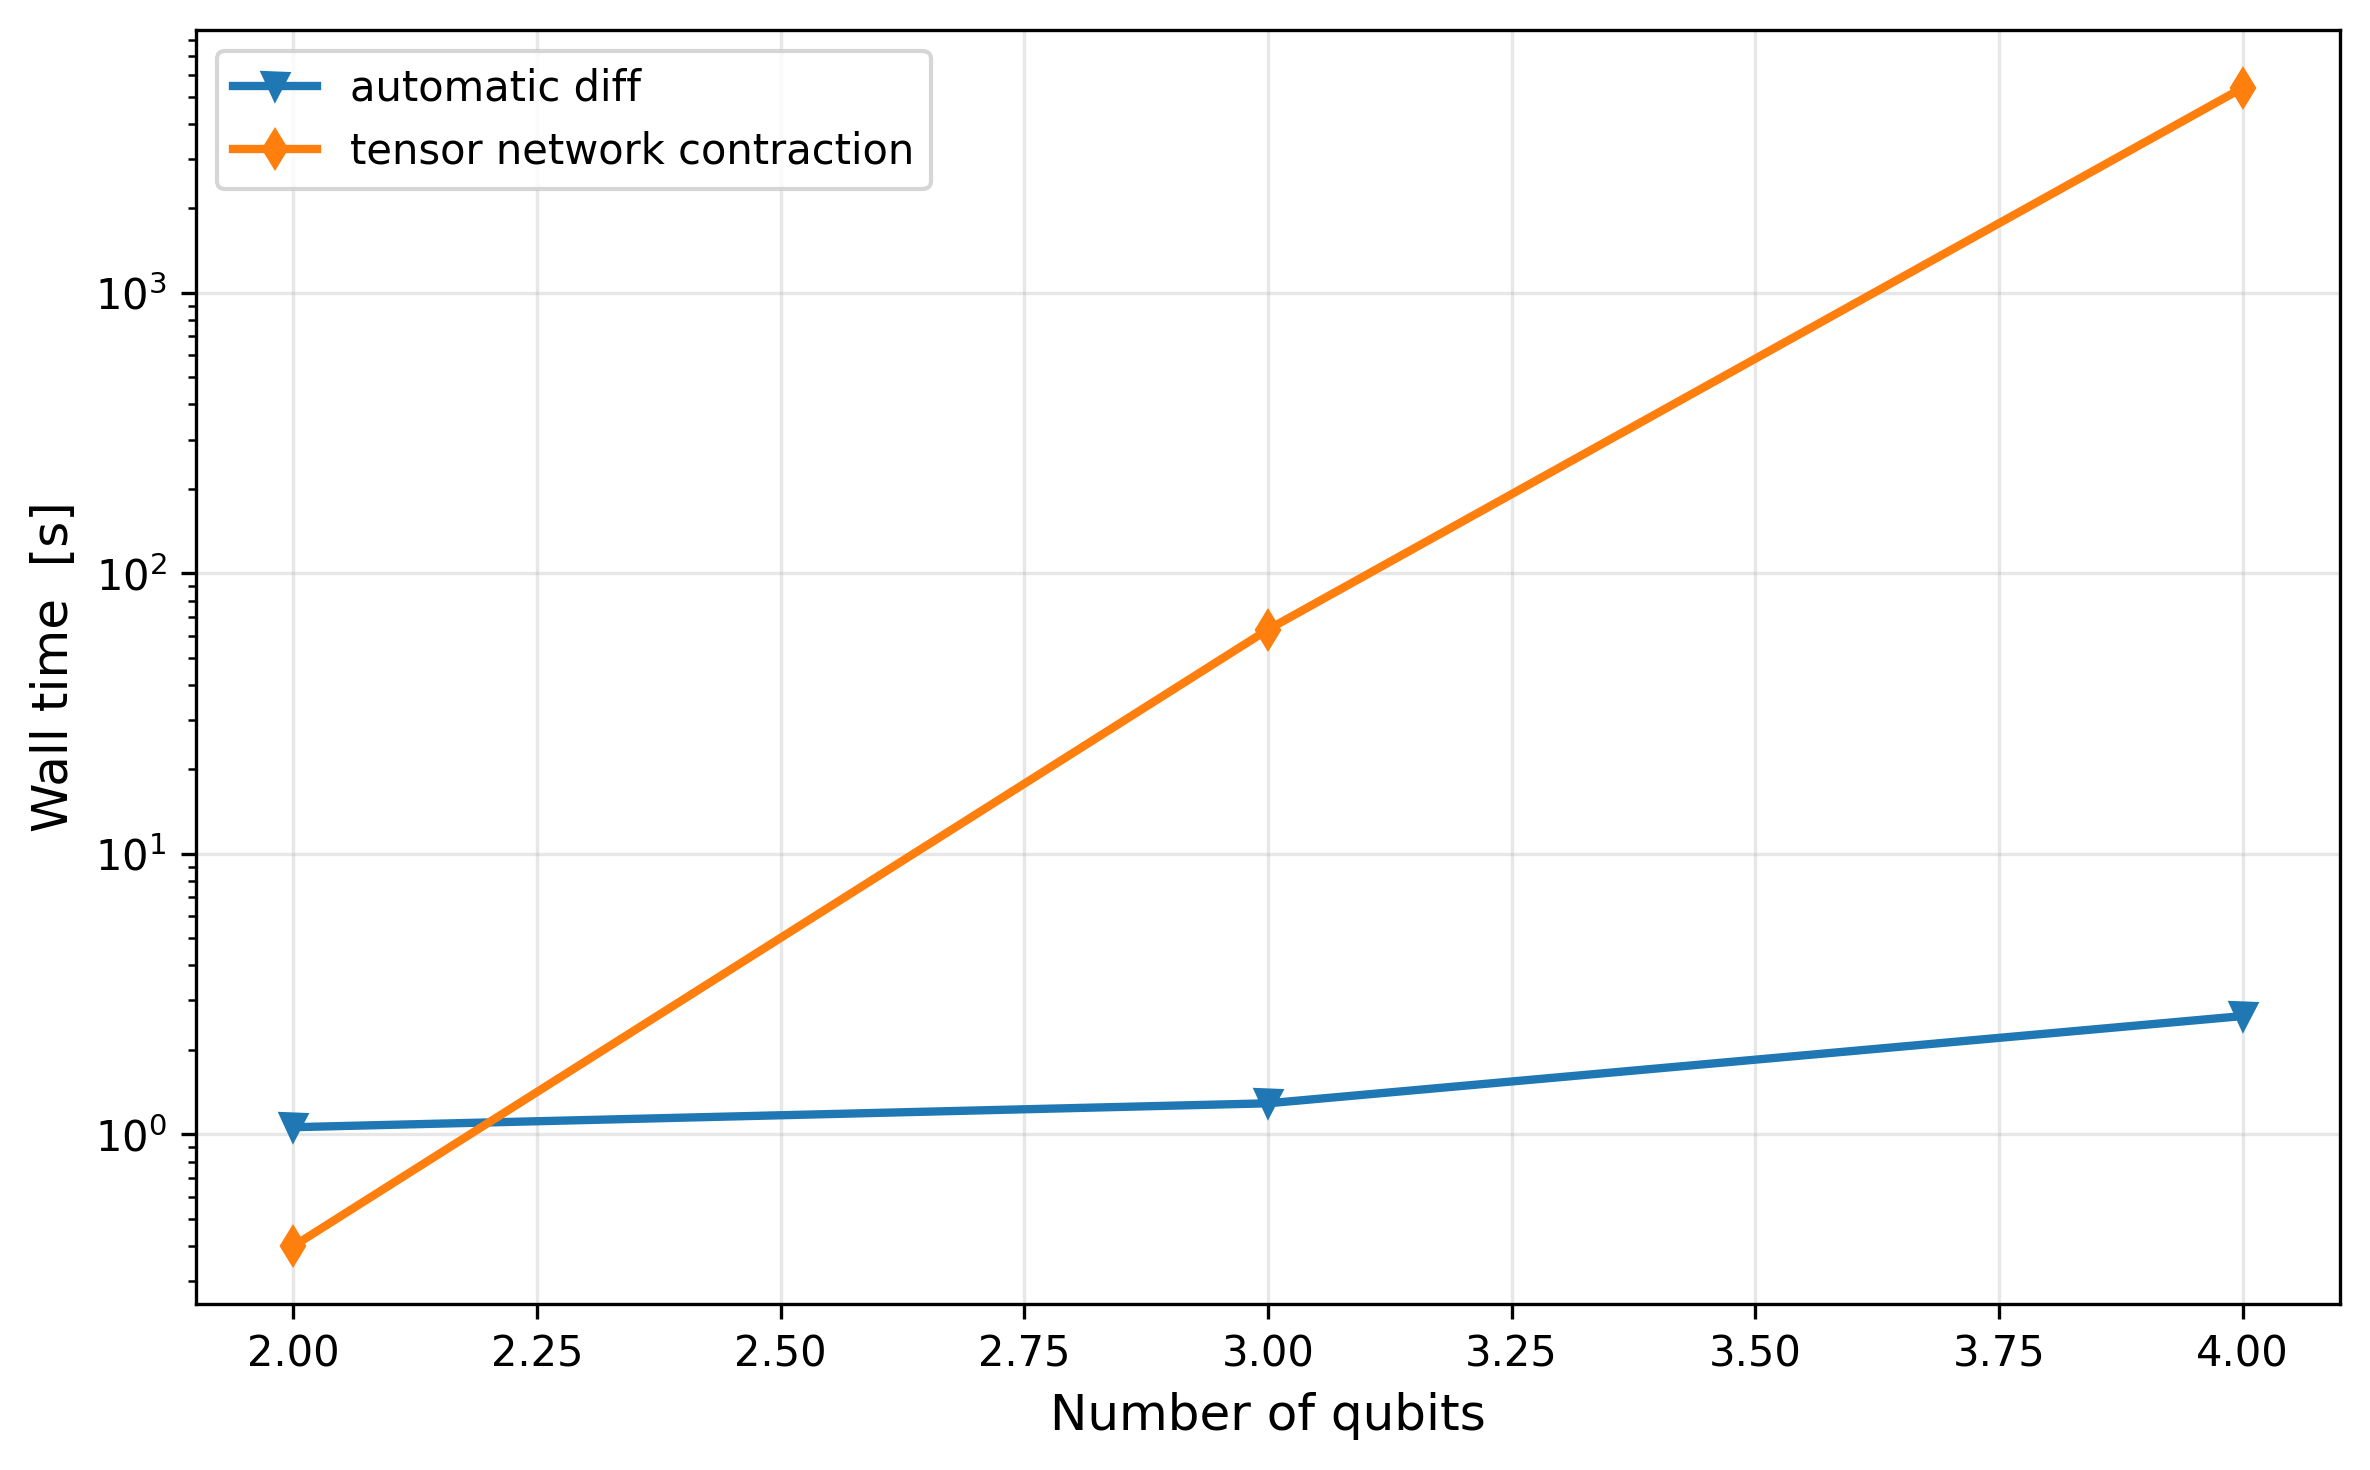

In [11]:
import jax.numpy as jnp
import matplotlib.pyplot as plt

cost_fn_compile_times_jax = jnp.array([1.08, 964e03, 1.12]) # how long it took the first time we ran it
cost_fn_times_jax = jnp.array([37.1, 51.9, 130])/1000
cost_fn_times_jax_nojit = jnp.array([680, 822, 1.68*1000])/1000 # new instance

cost_fn_compile_times_numba = jnp.array([524e-3, 1.35, 29.9]) #these values might not mean what I think they mean
cost_fn_times_numba = jnp.array([8.84, 916, 31.2e3])/1000

grad_compile_times_jax = jnp.array([4.57, 4.58, 6.72])
grad_times_jax = jnp.array([1.06, 1.29, 2.64])
grad_times_jax_nojit = jnp.array([6.29, 7.96, 16.2]) # new instance

grad_and_value_time_4q_jit = 7.41 # new instance for 4q
grad_and_value_time_4q_no_jit = 16.4 # new instance for 4q

grad_compile_times_numba = jnp.array([2.14, 71])
grad_times_numba = jnp.array([399e-3, 63, 89.63*60])


# Create the plot
plt.figure(figsize=(8, 5), dpi=300)

max_num_qubits = 4

plt.semilogy(range(2, max_num_qubits+1), grad_times_jax, label="automatic diff", linestyle="-", marker="v", linewidth=2, markersize=6)
plt.semilogy(range(2, max_num_qubits+1), grad_times_numba, label="tensor network contraction", linestyle="-", marker="d", linewidth=2, markersize=6)

# Add labels, legend, and grid
plt.xlabel("Number of qubits", fontsize=12)
plt.ylabel("Wall time  [s]", fontsize=12)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)

# Show the plot
plt.tight_layout()
plt.show()

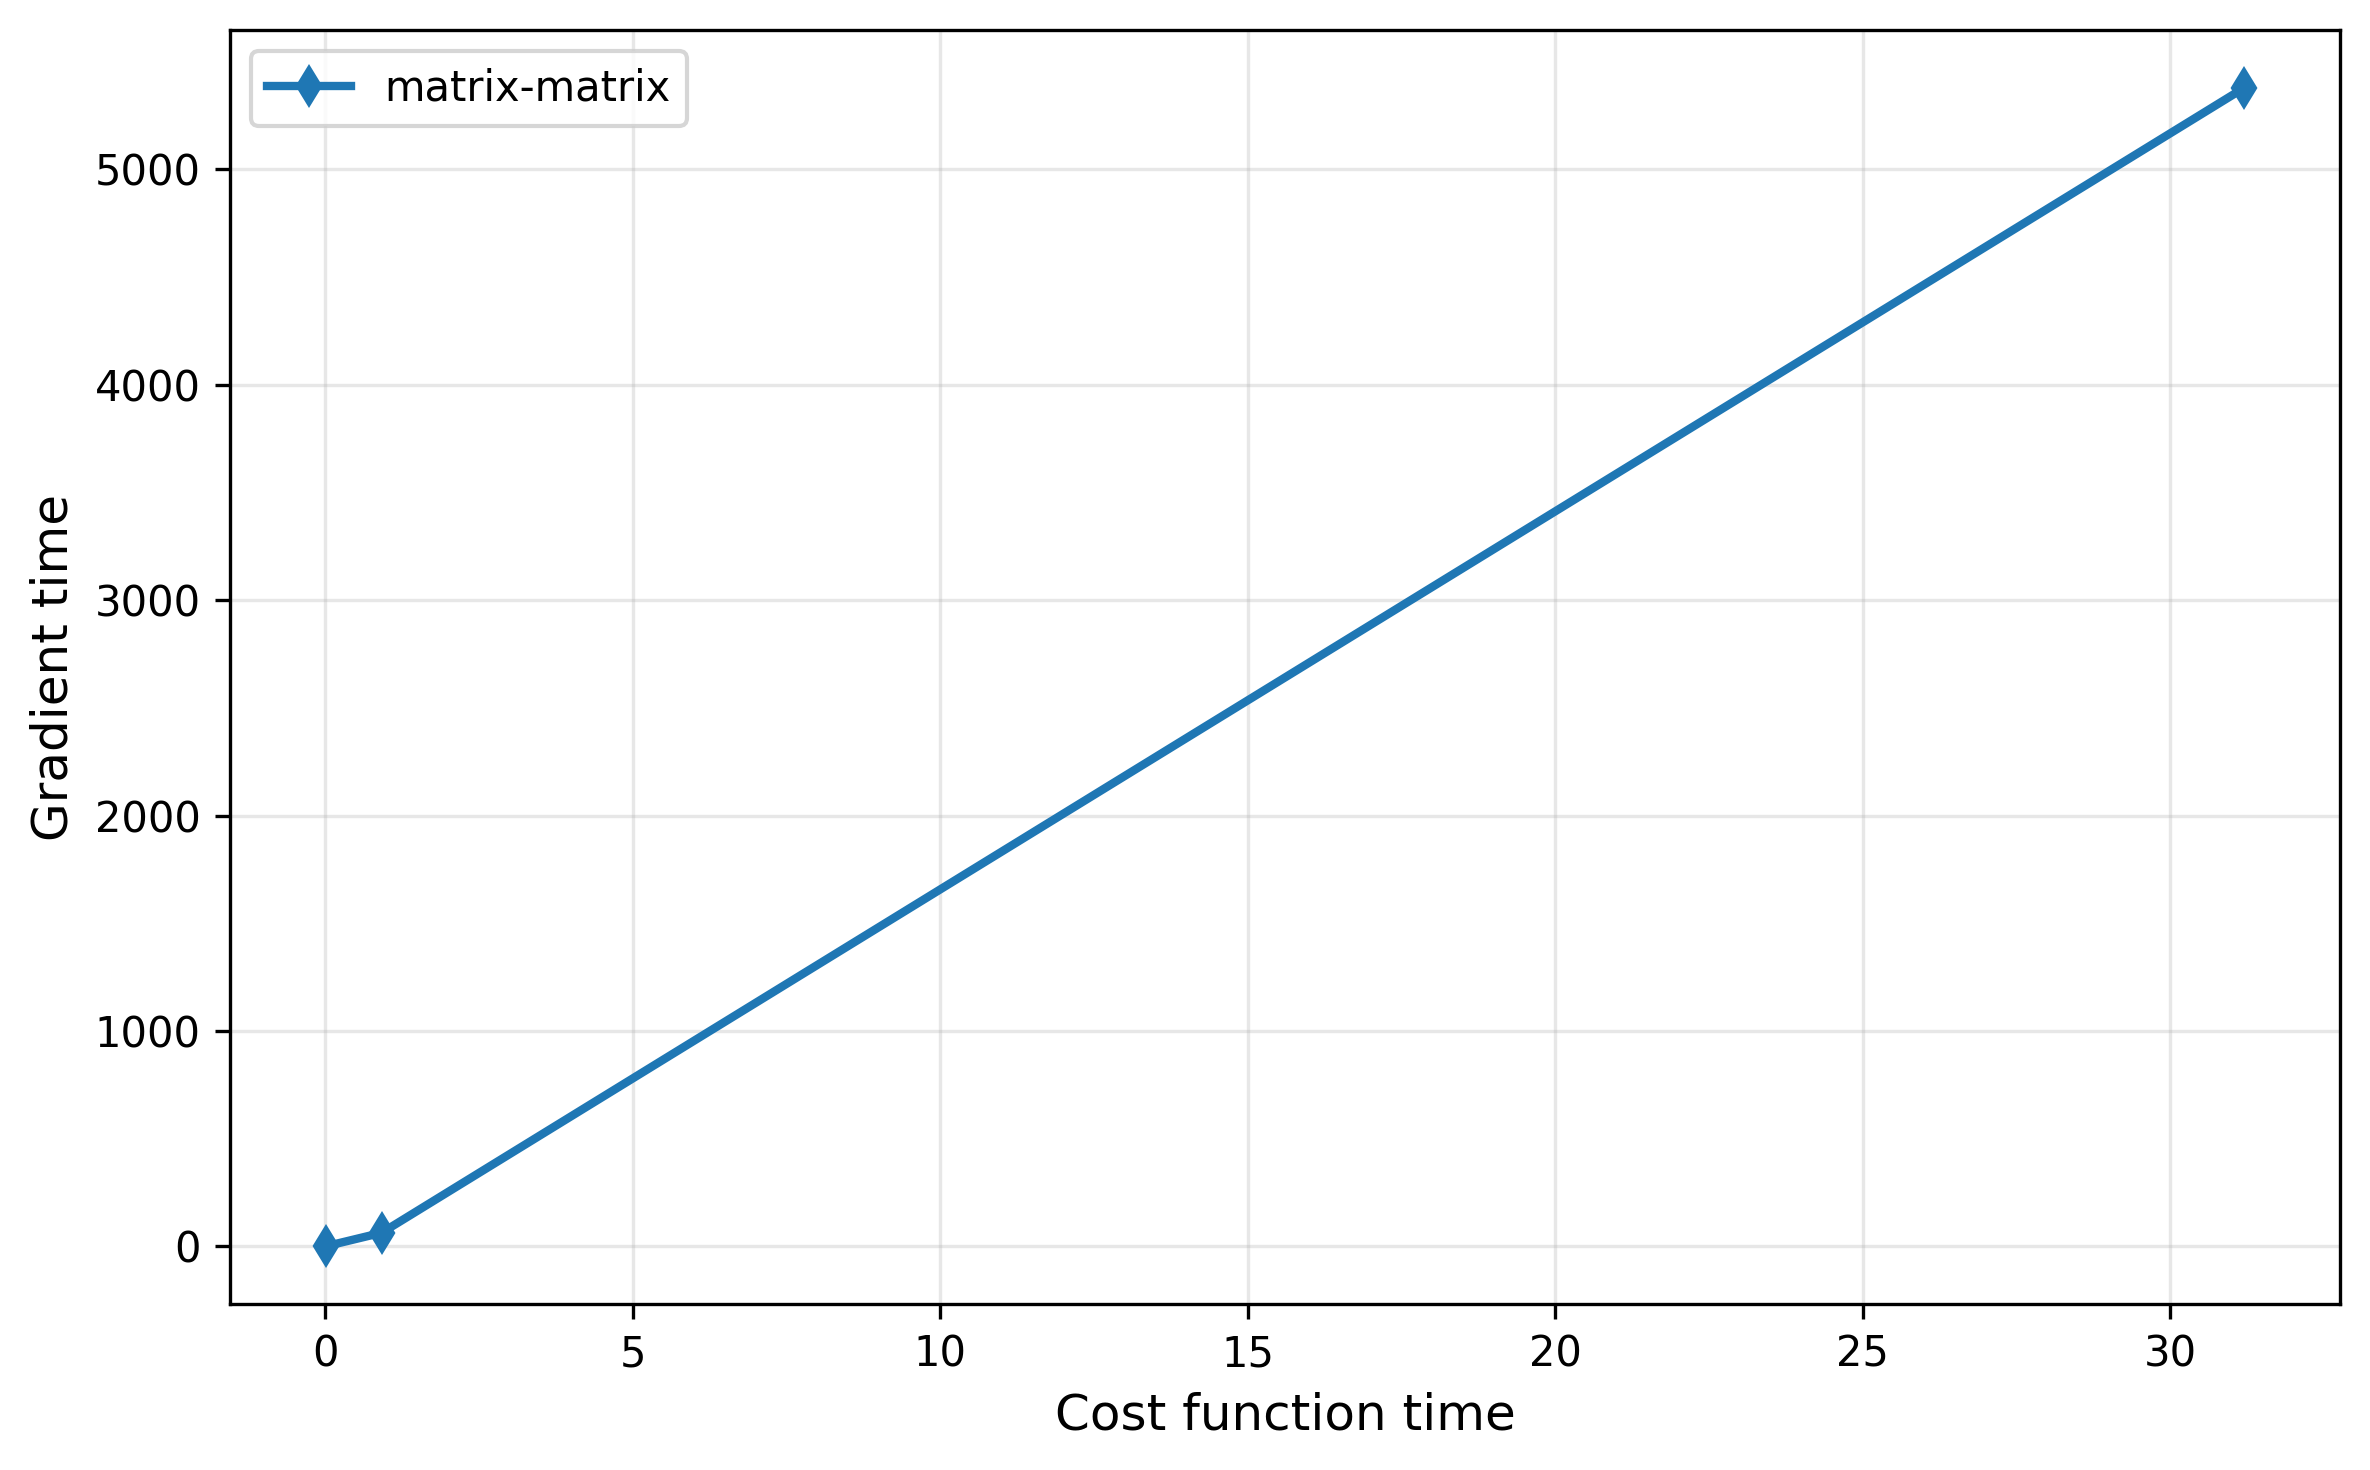

[28.571428 24.85549  20.307693]
[9.25     9.683698 9.642858]
[ 45.135742  68.77729  172.36537 ]


In [14]:
# Create the plot
plt.figure(figsize=(8, 5), dpi=300)

max_num_qubits = 4

# plt.plot(cost_fn_times_jax, grad_times_jax, label="jax", linestyle="-", marker="v", linewidth=2, markersize=6)
# plt.plot(cost_fn_times_jax_nojit, grad_times_jax_nojit, label="MPS-JAX", linestyle="-", marker="d", linewidth=2, markersize=6)
plt.plot(cost_fn_times_numba, grad_times_numba, label="matrix-matrix", linestyle="-", marker="d", linewidth=2, markersize=6)

# Add labels, legend, and grid
plt.xlabel("Cost function time", fontsize=12)
plt.ylabel("Gradient time", fontsize=12)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)

# Show the plot
plt.tight_layout()
plt.show()

print(grad_times_jax/cost_fn_times_jax)
print(grad_times_jax_nojit/cost_fn_times_jax_nojit)
print(grad_times_numba/cost_fn_times_numba)

In [44]:
len(indices_list[-1])

14

# Attempt at full GDS optimization of 4Q GST

In [20]:
from mGST.utility_functions_comparisons import run_simple_gds_on_gates_jax, check_kraus_tensor_is_isometry

In [41]:
kraus_opt_no_ls, cost_fn_history_no_ls = run_simple_gds_on_gates_jax(kraus_tensor=K, povm_psd=povm_tensor, state_psd=state, indices_list=indices_list, prob_matrix=y, max_iter=250, target_rel_prec=1e-3, step_size=50, optimize_step=False)

iteration:  0
Initial count: 15
cost:  0.0005244347375226987
iteration:  1
Initial count: 15
cost:  0.00048369890507389616
iteration:  2
Initial count: 15
cost:  0.00046427405023615587
iteration:  3
Initial count: 15
cost:  0.0004516119521977333
iteration:  4
Initial count: 15
cost:  0.00044250322750727275
iteration:  5
Initial count: 15
cost:  0.00043550988112541443
iteration:  6
Initial count: 15
cost:  0.0004298756933157759
iteration:  7
Initial count: 15
cost:  0.00042515961524893
iteration:  8
Initial count: 15
cost:  0.00042108496626480684
iteration:  9
Initial count: 15
cost:  0.0004174687542016464
iteration:  10
Initial count: 15
cost:  0.00041418520048359285
iteration:  11
Initial count: 15
cost:  0.0004111455779573289
iteration:  12
Initial count: 15
cost:  0.0004082865166914724
iteration:  13
Initial count: 15
cost:  0.00040556297000247644
iteration:  14
Initial count: 15
cost:  0.000402943817502806
iteration:  15
Initial count: 15
cost:  0.000400408935573158
iteration:  16


Text(0, 0.5, 'Cost function')

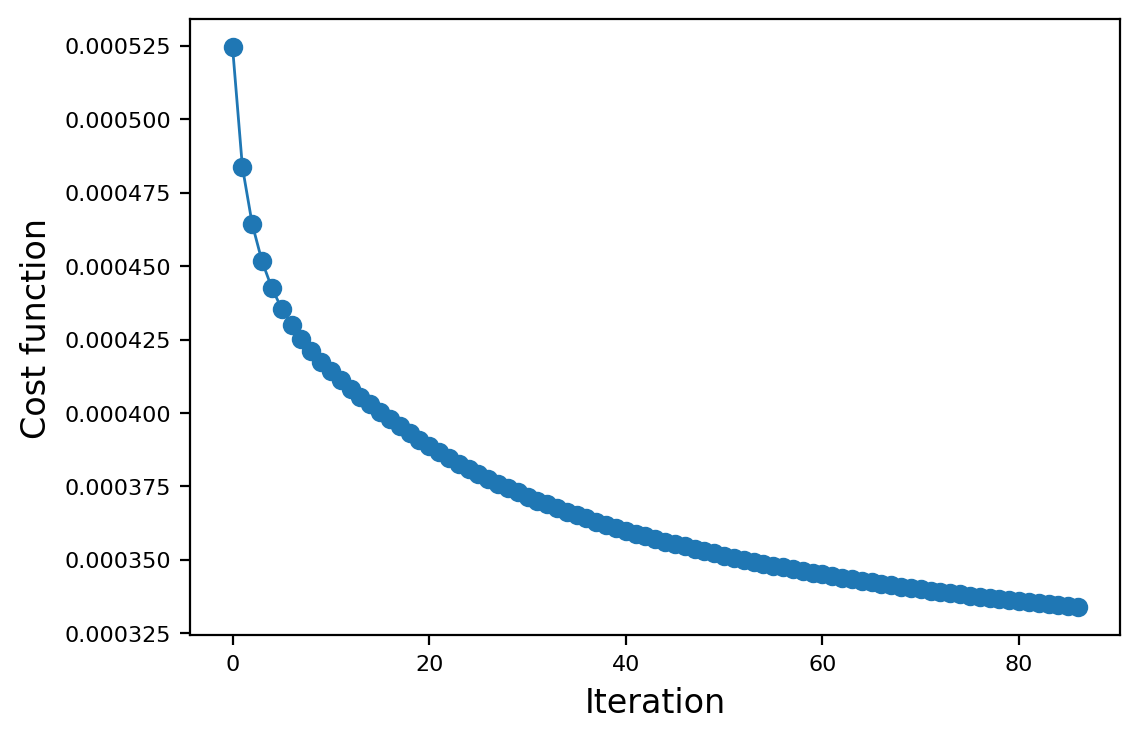

In [42]:
plt.figure(figsize=(6, 4), dpi=200)
plt.plot(cost_fn_history_no_ls, marker="o", linestyle="-", linewidth=1, markersize=6)
plt.xlabel("Iteration", fontsize=12)
plt.ylabel("Cost function", fontsize=12)

In [17]:
kraus_opt, cost_fn_history = run_simple_gds_on_gates_jax(kraus_tensor=K, povm_psd=povm_tensor, state_psd=state, indices_list=indices_list, prob_matrix=y, max_iter=200, target_rel_prec=1e-3)

Initial count: 0
at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 10 the new count changed to: 3
at iteration 91 the new count changed to: 4
at iteration 242 the new count changed to: 5
at iteration 393 the new count changed to: 6
at iteration 544 the new count changed to: 7
at iteration 696 the new count changed to: 8
at iteration 848 the new count changed to: 9
at iteration 1000 the new count changed to: 10
at iteration 1166 the new count changed to: 11
at iteration 1332 the new count changed to: 12
at iteration 1499 the new count changed to: 13
at iteration 1666 the new count changed to: 14
at iteration 1833 the new count changed to: 15
iteration:  0
cost:  0.0005244347375226986
Using JAX power
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial c

In [23]:
all(check_kraus_tensor_is_isometry(kraus_tensor) for kraus_tensor in kraus_opt)

True

In [44]:
optimized_step_sizes = [
    20.0, 39.0, 58.0, 77.0, 96.0, 115.0, 134.0, 153.0, 172.0, 154.0,
    136.0, 118.0, 100.0, 82.0, 64.0, 46.0, 65.0, 84.0, 103.0, 86.5,
    71.0, 85.0, 70.5, 84.375, 70.0, 84.125, 69.625, 84.0, 69.5, 83.625,
    69.5, 83.4375, 69.3125, 83.5625, 69.0625, 83.8125, 68.8125, 83.8125,
    68.8125, 83.5625, 68.8125, 83.3125, 68.8125, 83.3125, 68.8125, 83.0625,
    68.9375, 82.6875, 68.9375, 82.5625, 69.0625, 82.25
] # obtained from chatGPT
len(optimized_step_sizes)

52

In [35]:
jnp.argmax(jnp.array(cost_fn_history)[1:])

Array(12, dtype=int64)

In [38]:
cost_fn_history[10:16]

[Array(0.00039369, dtype=float64),
 Array(0.00040846, dtype=float64),
 Array(0.00045957, dtype=float64),
 Array(0.00051636, dtype=float64),
 Array(0.00049533, dtype=float64),
 Array(0.00039997, dtype=float64)]

In [43]:
cost_fn_history[-1], cost_fn_history_no_ls[-1]

(Array(0.00032725, dtype=float64), Array(0.00033383, dtype=float64))

Text(0, 0.5, 'Cost function')

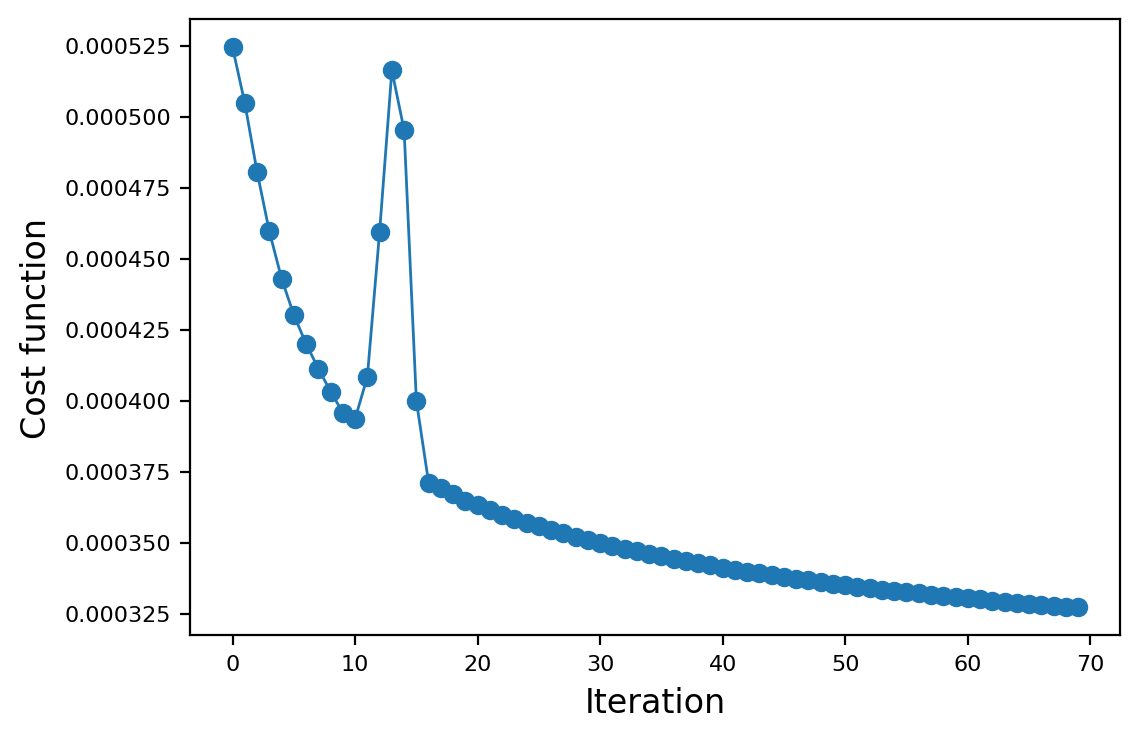

In [32]:
plt.figure(figsize=(6, 4), dpi=200)
plt.plot(cost_fn_history, marker="o", linestyle="-", linewidth=1, markersize=6)
plt.xlabel("Iteration", fontsize=12)
plt.ylabel("Cost function", fontsize=12)

In [71]:
kraus_opt, cost_fn_history = run_simple_gds_on_gates_jax(kraus_tensor=K, povm_psd=povm_tensor, state_psd=state, indices_list=indices_list, prob_matrix=y, max_iter=200, target_rel_prec=1e-3)

iteration:  0
cost:  0.0005064360236820644
Using JAX power
optimized step size:  [20.]
iteration:  1
cost:  0.0004917805134796169
Using JAX power
optimized step size:  [39.]
iteration:  2
cost:  0.0004732196024974859
Using JAX power
optimized step size:  [58.]
iteration:  3
cost:  0.000456771262059096
Using JAX power
optimized step size:  [77.]
iteration:  4
cost:  0.00044354881299336245
Using JAX power
optimized step size:  [96.]
iteration:  5
cost:  0.0004328829961834032
Using JAX power
optimized step size:  [115.]
iteration:  6
cost:  0.000423791515261142
Using JAX power
optimized step size:  [134.]
iteration:  7
cost:  0.00041556002267309543
Using JAX power
optimized step size:  [153.]
iteration:  8
cost:  0.0004077120974329044
Using JAX power
optimized step size:  [172.]
iteration:  9
cost:  0.00040049114520095564
Using JAX power
optimized step size:  [154.]
iteration:  10
cost:  0.00039881250831087095
Using JAX power
optimized step size:  [136.]
iteration:  11
cost:  0.0004163087

From previous optimization:
- iteration:  10
cost:  0.00039881250831087095
Using JAX power
optimized step size:  [136.]
- iteration:  11
cost:  0.0004163087053681331
Using JAX power
optimized step size:  [118.]
- iteration:  12
    cost:  0.0004778646753267904
    Using JAX power
    optimized step size:  [100.]
- iteration:  13
    cost:  0.0005569598066551488
    Using JAX power
    optimized step size:  [82.]
- iteration:  14
    cost:  0.0005308786286912757
    Using JAX power
    optimized step size:  [64.]
- iteration:  15
cost:  0.00041646785593505765
Using JAX power
optimized step size:  [46.]
- iteration:  16
cost:  0.0003755051405346419
Using JAX power
optimized step size:  [65.]

In [48]:
# list from chatGPT (it could only get values up to th 60th iteration):
optimized_step_sizes_old = [
    20.0, 39.0, 58.0, 77.0, 96.0, 115.0, 134.0, 153.0, 172.0, 154.0, 136.0, 
    118.0, 100.0, 82.0, 64.0, 46.0, 65.0, 84.0, 103.0, 85.0, 67.0, 81.375, 
    75.015625, 81.25195312, 74.95507812, 81.11523438, 74.91601562, 81.01171875, 
    74.89453125, 80.91699219, 74.88183594, 80.83691406, 74.87207031, 80.75878906, 
    74.86816406, 80.68261719, 74.86230469, 80.61328125, 74.8515625, 80.5546875, 
    74.8359375, 80.4921875, 74.828125, 80.42578125, 74.81640625, 80.37109375, 
    74.80078125, 80.31347656, 74.78613281, 80.26269531, 74.76757812, 80.20898438, 
    74.75585938, 80.15039062, 74.74804688, 80.09179688, 74.74023438, 80.03320312, 
    74.73632812, 79.97070312
]
len(optimized_step_sizes_old)

60

In [56]:
optimized_step_sizes_old[:19] == optimized_step_sizes[:19]

True

Text(0, 0.5, 'Cost function')

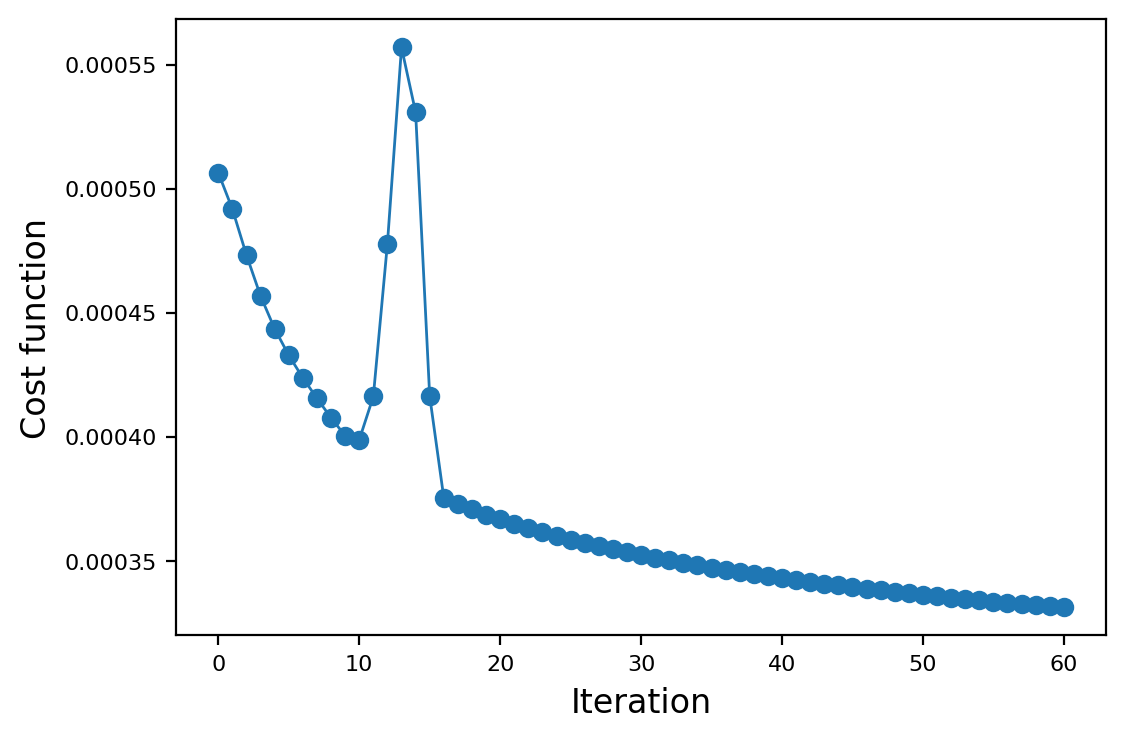

In [57]:
# ChatGPT values
cost_function_values_old = [
    0.0005064360236820644, 0.0004917805134796169, 0.0004732196024974859, 
    0.000456771262059096, 0.00044354881299336245, 0.0004328829961834032, 
    0.000423791515261142, 0.00041556002267309543, 0.0004077120974329044, 
    0.00040049114520095564, 0.00039881250831087095, 0.0004163087053681331, 
    0.0004778646753267904, 0.0005569598066551488, 0.0005308786286912757, 
    0.00041646785593505765, 0.0003755051405346419, 0.0003731280439085466, 
    0.0003708292916201227, 0.00036858160065897144, 0.0003667651201224294, 
    0.00036484232078329336, 0.00036316350586557437, 0.00036157347655258506, 
    0.0003600640011708515, 0.00035862884871729983, 0.0003572614400004708, 
    0.0003559569247501817, 0.00035471005509007616, 0.0003535169892153213, 
    0.00035237349782207947, 0.0003512764890689542, 0.0003502225125074342, 
    0.00034920906911667187, 0.0003482333197993549, 0.00034729322598684207, 
    0.0003463864226618183, 0.00034551123170228405, 0.00034466566166417204, 
    0.0003438483240396193, 0.0003430575200658908, 0.0003422920919344399, 
    0.00034155058430301427, 0.00034083202251524304, 0.0003401351408729694, 
    0.00033945910898934507, 0.00033880281408646623, 0.0003381655488181427, 
    0.0003375463347261668, 0.0003369445587697934, 0.00033635934954341596, 
    0.0003357901732542316, 0.0003352362554933553, 0.000334697128466308, 
    0.0003341720955855106, 0.00033366074445697615, 0.0003331624453756234, 
    0.00033267683194877393, 0.00033220333457381726, 0.0003317416263226457, 
    0.00033129119052919734
]

plt.figure(figsize=(6, 4), dpi=200)
plt.plot(cost_function_values_old, marker="o", linestyle="-", linewidth=1, markersize=6)
plt.xlabel("Iteration", fontsize=12)
plt.ylabel("Cost function", fontsize=12)

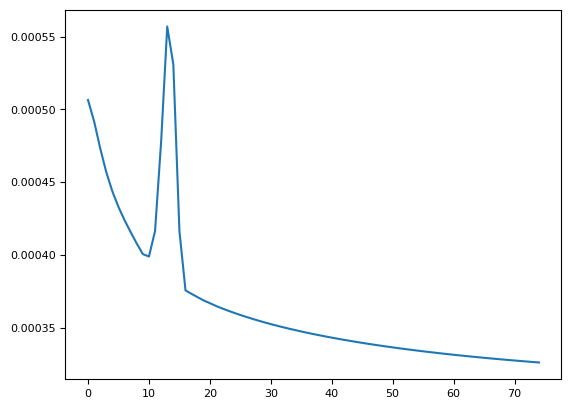

In [72]:
plt.plot(cost_fn_history)

In [73]:
(cost_fn_history[0]-cost_fn_history[-1])/cost_fn_history[0]

Array(0.35632009, dtype=float64)

# Optimization with Polar decomposition

In [84]:
from mGST.utility_functions_comparisons import factorize_psd_truncated, run_simple_gds_on_gates_jax
from mGST.low_level_jit import cost_function_jax_mps, cost_function_numba, gradient_k_and_value_nojit, gradient_k_and_value_jit
from mGST.algorithm import gradient_descent_step

%load_ext autoreload
%autoreload 2

state_psd = factorize_psd_truncated(psd=state, max_rank=1)
povm_psd  = factorize_psd_truncated(psd=povm_tensor, max_rank=1)
kraus_tensor = K
prob_matrix = y

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [70]:
%timeit cost_function_jax_mps(kraus_tensor, povm_psd, state_psd, indices_list, prob_matrix, jit=False)

jax power
jax power
jax power
jax power
jax power
jax power
jax power
jax power
1.86 s ± 41.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [78]:
%timeit cost_function_jax_mps(kraus_tensor, povm_psd, state_psd, indices_list, prob_matrix, jit=True)

Initial count: 0
jax power
at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 10 the new count changed to: 3
at iteration 91 the new count changed to: 4
at iteration 242 the new count changed to: 5
at iteration 393 the new count changed to: 6
at iteration 544 the new count changed to: 7
at iteration 696 the new count changed to: 8
at iteration 848 the new count changed to: 9
at iteration 1000 the new count changed to: 10
at iteration 1166 the new count changed to: 11
at iteration 1332 the new count changed to: 12
at iteration 1499 the new count changed to: 13
at iteration 1666 the new count changed to: 14
at iteration 1833 the new count changed to: 15
Initial count: 15
jax power
Initial count: 15
jax power
Initial count: 15
jax power
Initial count: 15
jax power
Initial count: 15
jax power
Initial count: 15
jax power
Initial count: 15
jax power
132 ms ± 1.61 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [72]:
cost_test = cost_function_jax_mps(kraus_tensor, povm_psd, state_psd, indices_list, prob_matrix, jit=False)
cost_test

jax power


Array(0.00052443, dtype=float64)

In [76]:
cost_value_numba_4q = cost_function_numba(K_np, E_np, rho_np, J, y_np)
cost_value_numba_4q

0.0005244347375227034

In [77]:
jnp.allclose(cost_test, cost_value_numba_4q)

Array(True, dtype=bool)

In [81]:
%timeit gradient_k_and_value_nojit(kraus_tensor, povm_psd, state_psd, indices_list, prob_matrix)

jax power
jax power
jax power
jax power
jax power
jax power
jax power
jax power
16.9 s ± 370 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [82]:
%timeit gradient_k_and_value_jit(kraus_tensor, povm_psd, state_psd, indices_list, prob_matrix)

Initial count: 15
jax power
Initial count: 15
jax power
Initial count: 15
jax power
Initial count: 15
jax power
Initial count: 15
jax power
Initial count: 15
jax power
Initial count: 15
jax power
Initial count: 15
jax power
2.9 s ± 121 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [86]:
%timeit gradient_descent_step(kraus_tensor, povm_psd, state_psd, indices_list, prob_matrix, optimize_step=False)

new version
Initial count: 15
jax power
new version
Initial count: 15
jax power
new version
Initial count: 15
jax power
new version
Initial count: 15
jax power
new version
Initial count: 15
jax power
new version
Initial count: 15
jax power
new version
Initial count: 15
jax power
new version
Initial count: 15
jax power
2.9 s ± 68 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
